# Comp1-传统组学

主要适配于传统组学的建模和刻画。典型的应用场景探究rad_score最最终临床诊断的作用。

数据的一般形式为(具体文件,文件夹名可以不同)：
1. `images`文件夹，存放研究对象所有的CT、MRI等数据。
2. `masks`文件夹, 存放手工（Manuelly）勾画的ROI区域。与images文件夹的文件意义对应。
3. `label.txt`文件，每个患者对应的标签，例如肿瘤的良恶性、5年存活状态等。

## Onekey步骤

1. 数据校验，检查数据格式是否正确。
2. 组学特征提取，如果第一步检查数据通过，则提取对应数据的特征。
3. 读取标注数据信息。
4. 特征与标注数据拼接。形成数据集。
5. 查看一些统计信息，检查数据时候存在异常点。
6. 正则化，将数据变化到服从 N~(0, 1)。
7. 通过相关系数，例如spearman、person等筛选出特征。
8. 构建训练集和测试集，这里使用的是随机划分，正常多中心验证，需要大家根据自己的场景构建两份数据。
9. 通过Lasso筛选特征，选取其中的非0项作为后续模型的特征。
10. 使用机器学习算法，例如LR、SVM、RF等进行任务学习。
11. 模型结果可视化，例如AUC、ROC曲线，混淆矩阵等。


In [1]:
## 获得视频教程
import os
os.environ['DISABLE_VIDEO'] = 'TRUE'
from onekey_algo.custom.Manager import onekey_show
onekey_show('传统组学任务')

[2026-02-27 19:41:57 - Manager.py: 159]	INFO	播放视频功能已经设置成：Disable！


## 一、数据校验
首先需要检查诊断数据，如果显示`检查通过！`择可以正常运行之后的，否则请根据提示调整数据。

**注意**：这里要求images和masks文件夹中的文件名必须一一对应。e.g. `1.nii.gz`为images中的一个文件，在masks文件夹必须也存在一个`1.nii.gz`文件。

当然也可以使用自定义的函数，获取解析数据。

In [2]:
# 数据检验视频
onekey_show('传统组学任务|数据检验')

[2026-02-27 19:41:57 - Manager.py: 159]	INFO	播放视频功能已经设置成：Disable！


### 指定数据

此模块有3个需要自己定义的参数

1. `mydir`: 数据存放的路径。
2. `labelf`: 每个样本的标注信息文件。
3. `labels`: 要让AI系统学习的目标，例如肿瘤的良恶性、T-stage等。

In [3]:
import os
import pandas as pd
from IPython.display import display
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd

os.makedirs('img', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('features', exist_ok=True)

# 设置任务Task前缀
task_type = 'Combined'
class_mapping = get_param_in_cwd('label_mapping')
# 设置数据目录
# mydir = r'你自己数据的路径'
mydir = get_param_in_cwd('radio_dir')
if mydir == okds.ct:
    print(f'正在使用Onekey数据：{okds.ct}，如果不符合预期，请修改目录位置！')
# 对应的标签文件
group_info = get_param_in_cwd('dataset_column') or 'group'
labelf = get_param_in_cwd('label_file') or os.path.join(mydir, 'label.csv')
# 读取标签数据列名
labels = [get_param_in_cwd('task_column') or 'label']

## 标注数据

数据以csv格式进行存储，这里如果是其他格式，可以使用自定义函数读取出每个样本的结果。

要求label_data为一个`DataFrame`格式，包括ID列以及后续的labels列，可以是多列，支持Multi-Task。

In [4]:
group_info = 'group'
label_data = pd.read_csv(labelf)
# label_data['ID'] = label_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
label_data['ID'] = label_data['ID'].map(lambda x: os.path.splitext(x)[0])
# g = pd.read_csv('ids.csv')
# label_data = pd.merge(label_data, g, on='ID', how='inner')
label_data = label_data[['ID', group_info] + labels]
label_data

,ID,group,label
0,陈博201803-202302,train,2.140
1,齐明旭201609-201802,train,1.386
2,姜心忠202202-202403,train,1.705
3,司振哲201906-202302,train,0.000
4,胡轩铖202208-202407,train,0.000
...,...,...,...
300,张颖泰20230525-20241024,test,1.705
301,赵恩笛20230915-20250105,test,1.099
302,赵鹏20200521-20241107,test,0.693
303,赵志男20230401-20241112,test,0.000


## 特征拼接 

将标注数据`label_data`与`rad_data`进行合并，得到训练数据。

**注意：** 
1. 需要删掉ID这一列
2. 如果发现数据少了，需要自行检查数据是否匹配。

In [5]:
from onekey_algo.custom.utils import print_join_info

rad_data = pd.read_csv('data/clinic_sel.csv')
dl_data = pd.read_csv('results/DL2D_densenet121.csv')[['ID', 'Prediction']]
rad_data = pd.merge(dl_data, rad_data, on='ID', how='inner')
print_join_info(rad_data, label_data)
# combined_data = pd.merge(rad_data, label_data, on=['ID'], how='inner')
combined_data = rad_data
# combined_data[['ID'] + selected_features[0]].to_csv('features/sel_habitat.csv', index=False)
ids = combined_data['ID']
combined_data = combined_data.drop(['ID'], axis=1)
# display(combined_data[labels].value_counts())
display(combined_data[group_info].value_counts())
combined_data

[2026-02-27 19:41:57 - __init__.py:  63]	WARNING	存在ID特征不完全匹配的问题！在左边不在右边的ID：[]；在右边不在左边的ID：['刘兴岩201806-202411', '卢崇博202401-202503', '卢立才201508-201708', '夏琳202201-202305', '年景春202108-202303', '曲智金201905-202502', '曲智金201911-202502', '曹骥201407-201701', '杨帆201410-201706', '杨立夫20240106-20250106', '梁晟充20230420-20230420', '池志东201605-202503', '苏帅202008-202312', '苏帅202107-202312', '袁方202307-202407', '赵原202307-202407', '郝忠智201606-202507']


train    168
val       71
test      49
Name: group, dtype: int64

,Prediction,HDL,Number_of_mSASSS_score_0,CRP,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Number_of_mSASSS_score_3,...,Chol_HDL,Number_of_mSASSS_score_2,Smoking,LDL,LDL_HDL,Number_of_mSASSS_score_1,Gender,Alcoholism,group,label
0,1.097,0.65,12.0,3.5,3,50,31.0,32,0.0,0,...,5.646,0.0,1,2.14,3.292,0.0,1,1,train,0.000
1,0.678,1.19,12.0,6.0,16,76,18.0,28,0.0,0,...,2.824,0.0,0,1.82,1.529,0.0,0,0,train,0.000
2,1.062,0.94,9.0,2.0,8,12,37.0,38,5.0,0,...,4.734,2.0,1,2.98,3.170,1.0,1,0,train,0.000
3,1.025,1.09,10.5,4.3,13,23,16.0,29,2.5,0,...,2.807,1.0,0,1.61,1.477,0.5,1,0,train,0.000
4,0.938,0.94,9.5,2.9,33,34,51.0,52,3.5,0,...,5.479,1.0,0,3.47,3.691,1.5,0,0,train,1.792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,0.971,0.81,0.0,30.8,14,19,16.0,32,36.0,12,...,3.889,0.0,1,1.87,2.309,0.0,1,0,val,0.000
284,0.829,1.22,12.0,15.6,24,12,25.0,26,0.0,0,...,3.148,0.0,1,2.03,1.664,0.0,1,0,test,0.000
285,1.195,0.90,12.0,15.1,13,27,27.0,27,0.0,0,...,4.211,0.0,1,2.66,2.956,0.0,1,0,test,1.386
286,0.846,1.06,12.0,3.0,2,12,24.0,26,0.0,0,...,3.519,0.0,1,2.34,2.208,0.0,1,0,test,0.000


## 获取到数据的统计信息

1. count，统计样本个数。
2. mean、std, 对应特征的均值、方差
3. min, 25%, 50%, 75%, max，对应特征的最小值，25,50,75分位数，最大值。

In [6]:
combined_data.describe()

,Prediction,HDL,Number_of_mSASSS_score_0,CRP,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Number_of_mSASSS_score_3,Chol,Chol_HDL,Number_of_mSASSS_score_2,Smoking,LDL,LDL_HDL,Number_of_mSASSS_score_1,Gender,Alcoholism,label
count,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000
mean,0.886,0.985,8.691,19.866,26.958,40.976,27.486,35.073,7.215,1.247,4.070,4.387,1.401,0.444,2.519,2.733,0.663,0.847,0.132,0.866
std,0.177,0.265,3.986,27.756,24.553,31.691,10.333,11.978,10.358,2.883,0.891,1.446,2.019,0.498,0.757,1.088,1.028,0.360,0.339,0.899
min,0.448,0.420,0.000,0.000,0.000,12.000,5.000,11.000,0.000,0.000,1.900,1.570,0.000,0.000,0.420,0.347,0.000,0.000,0.000,0.000
25%,0.769,0.818,6.500,3.300,8.000,16.000,20.750,26.000,0.000,0.000,3.488,3.400,0.000,0.000,2.027,1.992,0.000,1.000,0.000,0.000
50%,0.889,0.950,10.000,10.300,20.000,28.000,26.000,33.000,2.000,0.000,3.985,4.166,0.000,0.000,2.510,2.594,0.000,1.000,0.000,0.805
75%,0.992,1.103,12.000,24.600,39.000,57.250,32.000,40.000,9.125,0.000,4.662,4.939,2.000,1.000,2.990,3.334,1.000,1.000,0.000,1.609
max,1.440,2.290,12.000,185.000,120.000,140.000,75.000,77.000,36.000,12.000,7.250,12.524,11.500,1.000,4.860,8.357,5.500,1.000,1.000,3.296


## 正则化

`normalize_df` 为onekey中正则化的API，将数据变化到0均值1方差。正则化的方法为

$column = \frac{column - mean}{std}$

In [7]:
from onekey_algo.custom.components.comp1 import normalize_df
data = normalize_df(combined_data, not_norm=labels, group=group_info, use_train=True)
data = data.dropna(axis=1)
data.to_csv(f'features/{task_type}feature_norm.csv', index=False)
data.describe()

[2026-02-27 19:41:57 - comp1.py: 283]	INFO	正在使用训练集预定数据进行标准化。


,Prediction,HDL,Number_of_mSASSS_score_0,CRP,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Number_of_mSASSS_score_3,Chol,Chol_HDL,Number_of_mSASSS_score_2,Smoking,LDL,LDL_HDL,Number_of_mSASSS_score_1,Gender,Alcoholism,label
count,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,2.880e+02,288.000,288.000,288.000,288.000,288.000
mean,-0.028,0.033,-0.002,-0.027,-0.060,-0.172,-0.009,-0.054,0.041,0.100,0.005,-0.009,-0.066,0.056,1.379e-02,0.008,-0.087,0.052,-0.107,0.866
std,0.946,1.037,1.060,0.992,0.956,0.937,0.887,0.951,1.108,1.172,1.003,1.011,0.953,1.007,1.028e+00,1.034,0.935,0.951,0.894,0.899
min,-2.364,-2.176,-2.313,-0.736,-1.110,-1.029,-1.939,-1.964,-0.732,-0.407,-2.435,-1.977,-0.728,-0.843,-2.836e+00,-2.261,-0.690,-2.183,-0.455,0.000
25%,-0.651,-0.621,-0.585,-0.619,-0.798,-0.911,-0.587,-0.774,-0.732,-0.407,-0.650,-0.698,-0.728,-0.843,-6.540e-01,-0.697,-0.690,0.455,-0.455,0.000
50%,-0.010,-0.103,0.346,-0.368,-0.331,-0.556,-0.136,-0.218,-0.518,-0.407,-0.090,-0.163,-0.728,-0.843,9.696e-04,-0.124,-0.690,0.455,-0.455,0.805
75%,0.541,0.493,0.877,0.142,0.409,0.310,0.379,0.337,0.245,-0.407,0.672,0.378,0.216,1.180,6.526e-01,0.578,0.219,0.455,-0.455,1.609
max,2.930,5.138,0.877,5.874,3.564,2.757,4.071,3.274,3.121,4.473,3.582,5.679,4.703,1.180,3.191e+00,5.352,4.311,0.455,2.183,3.296


## 统计检验

通过ttest或者utest进行特征筛选。

**注意** ：此步骤不是论文的标配，所以用不用在自己的选择，可以通过修改pvalue的值进行调整，默认是0.05为显著。

In [8]:
import seaborn as sns
from onekey_algo.custom.components.stats import clinic_stats

sub_data = data[data[group_info] == 'train']
# stats = clinic_stats(sub_data, stats_columns=list(data.columns[0:-2]), label_column=labels[0], 
#                      continuous_columns=list(data.columns[0:-2]))
# stats

### 相关系数

计算相关系数的方法有3种可供选择
1. pearson （皮尔逊相关系数）: standard correlation coefficient

2. kendall (肯德尔相关性系数) : Kendall Tau correlation coefficient

3. spearman (斯皮尔曼相关性系数): Spearman rank correlation

三种相关系数参考：https://blog.csdn.net/zmqsdu9001/article/details/82840332

In [9]:
# 相关系数视频
onekey_show('传统组学任务|相关系数')

[2026-02-27 19:41:57 - Manager.py: 159]	INFO	播放视频功能已经设置成：Disable！


In [10]:
pearson_corr = sub_data[[c for c in sub_data.columns if c not in labels]].corr('pearson')
# kendall_corr = data[[c for c in data.columns if c not in labels]].corr('kendall')
# spearman_corr = data[[c for c in data.columns if c not in labels]].corr('spearman')

### 相关系数可视化

通过修改变量名，可以可视化不同相关系数下的相关矩阵。

**注意**：当特征特别多的时候（大于100），尽量不要可视化，否则运行时间会特别长。

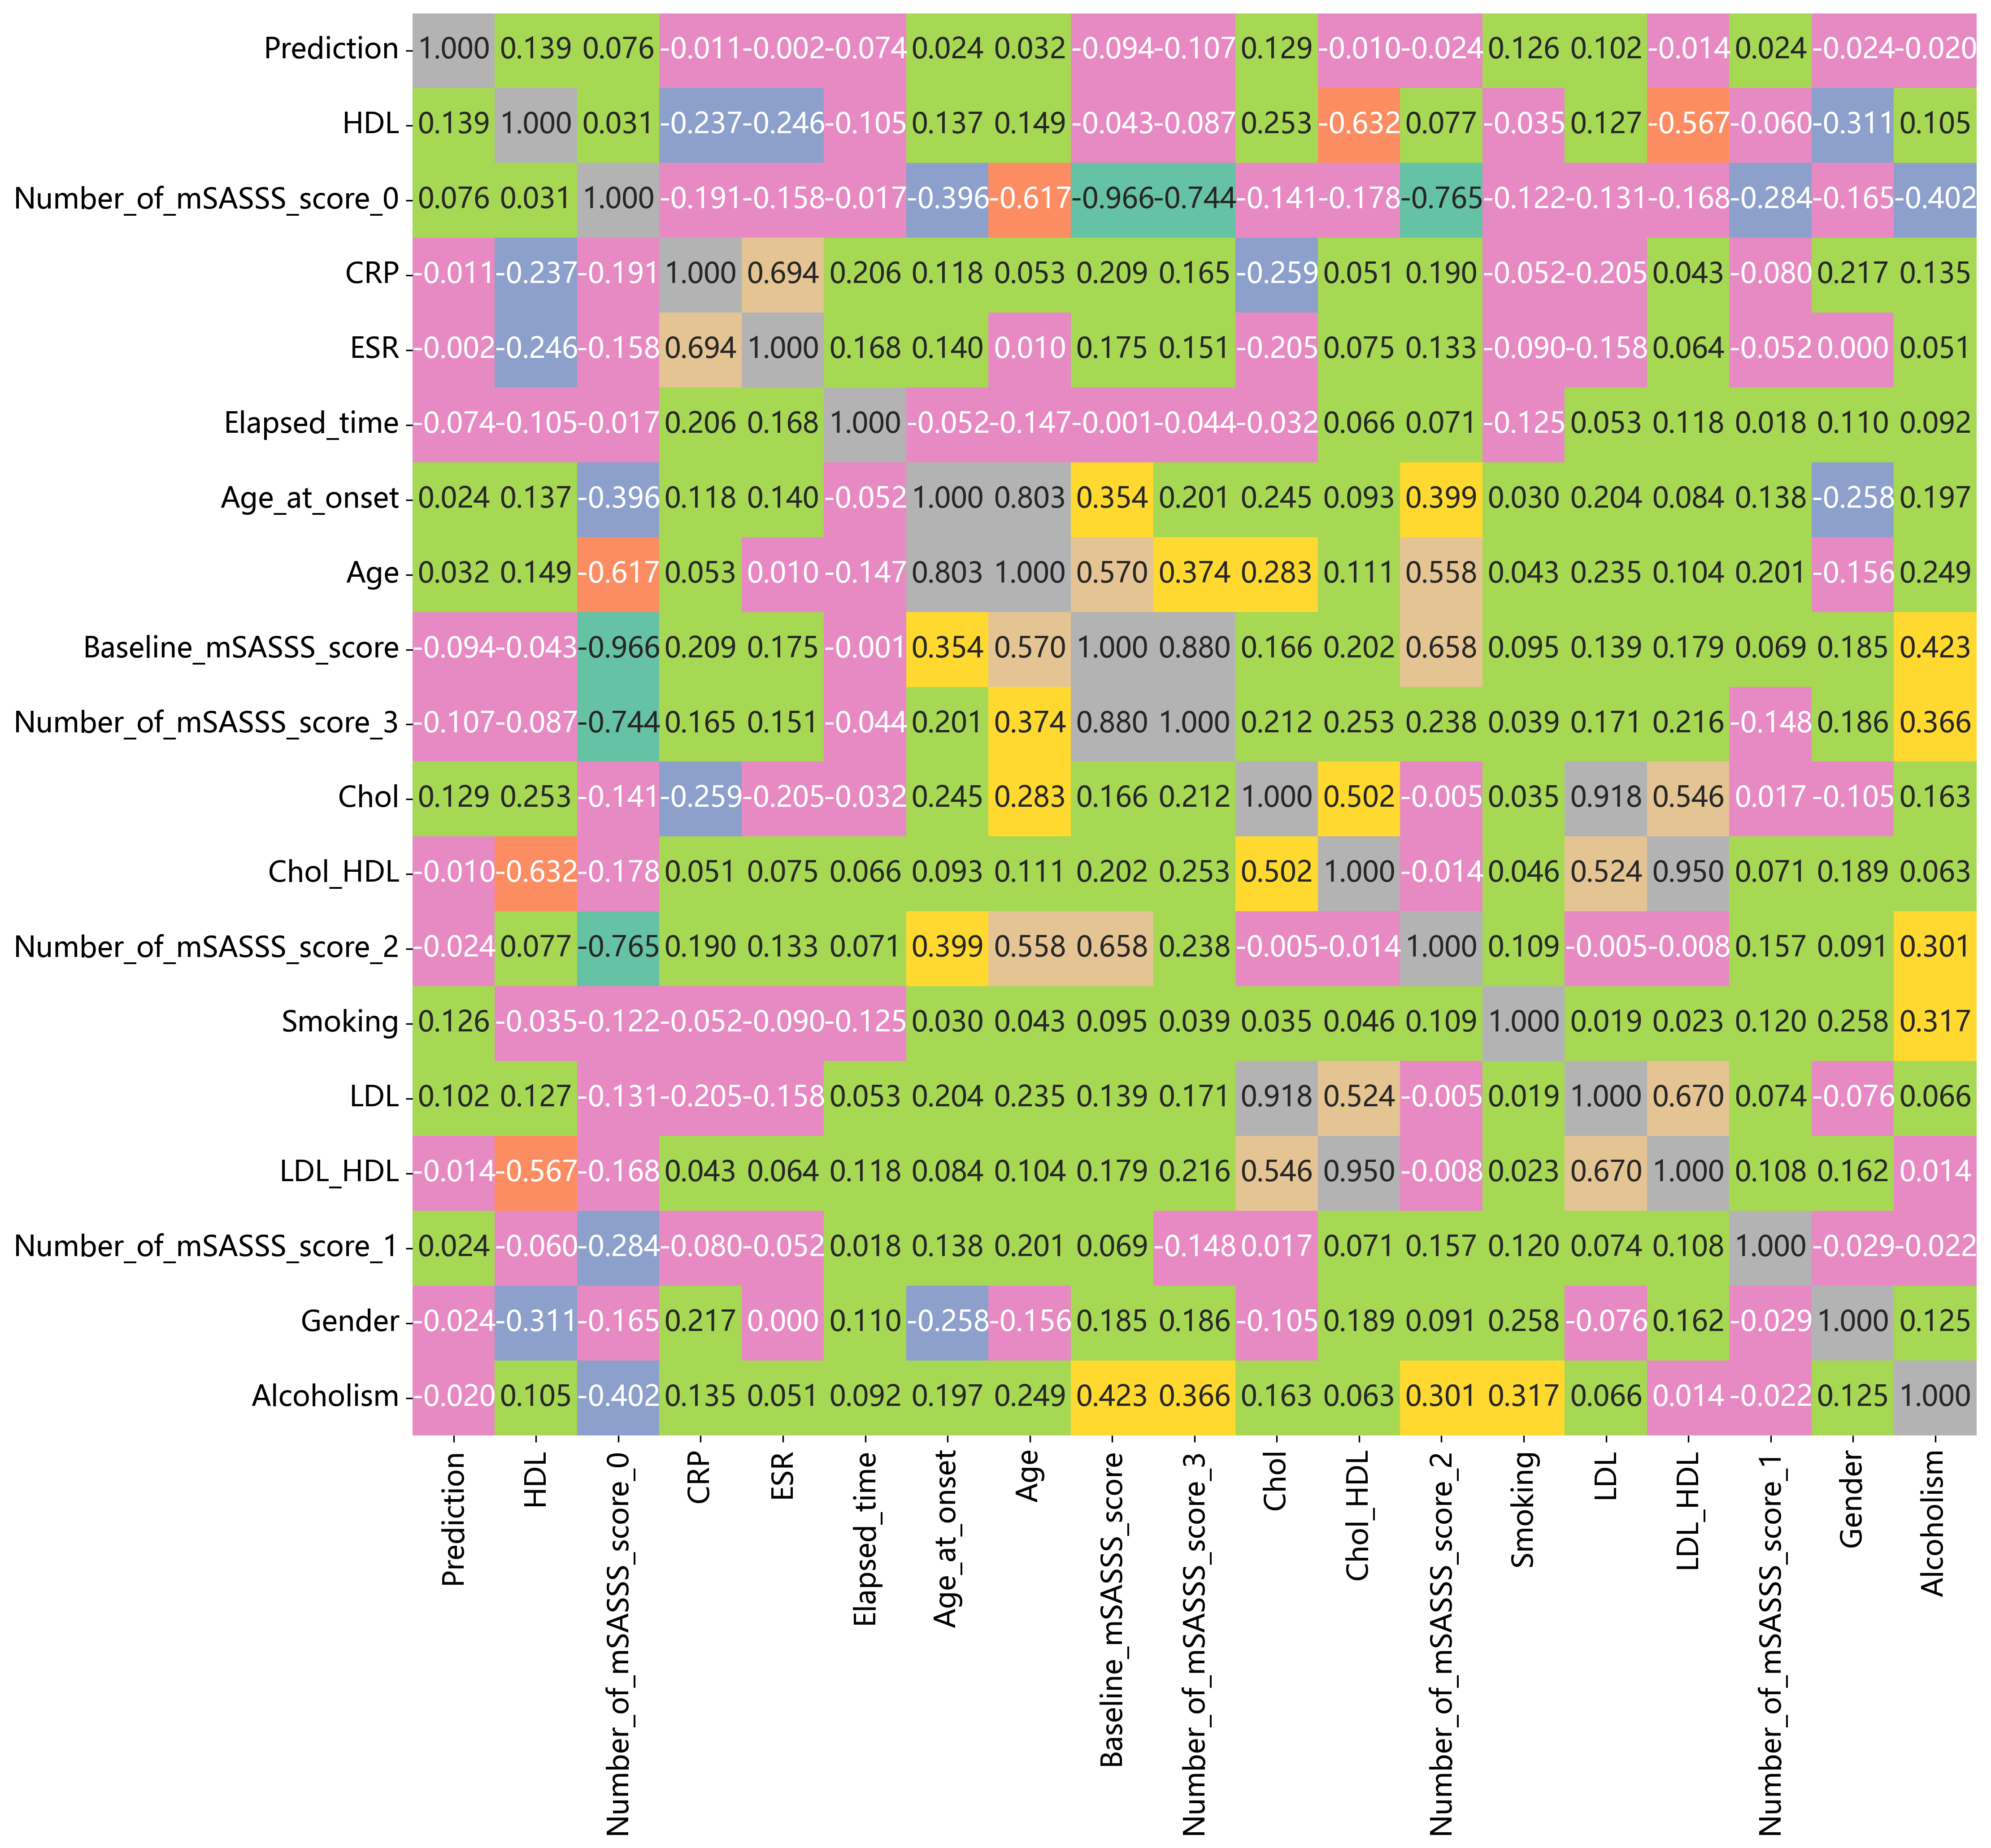

In [11]:
import seaborn as sns
from matplotlib import pyplot as plt
from onekey_algo.custom.components.comp1 import draw_matrix

if data.shape[1] < 100:
    plt.figure(figsize=(15.0, 14.0))

    # 选择可视化的相关系数
    draw_matrix(pearson_corr, annot=True, cmap='YlGnBu', cbar=False)
    plt.savefig(f'img/{task_type}Rad_feature_corr.svg', bbox_inches = 'tight')

### 聚类分析

通过修改变量名，可以可视化不同相关系数下的相聚类分析矩阵。

注意：当特征特别多的时候（大于100），尽量不要可视化，否则运行时间会特别长。

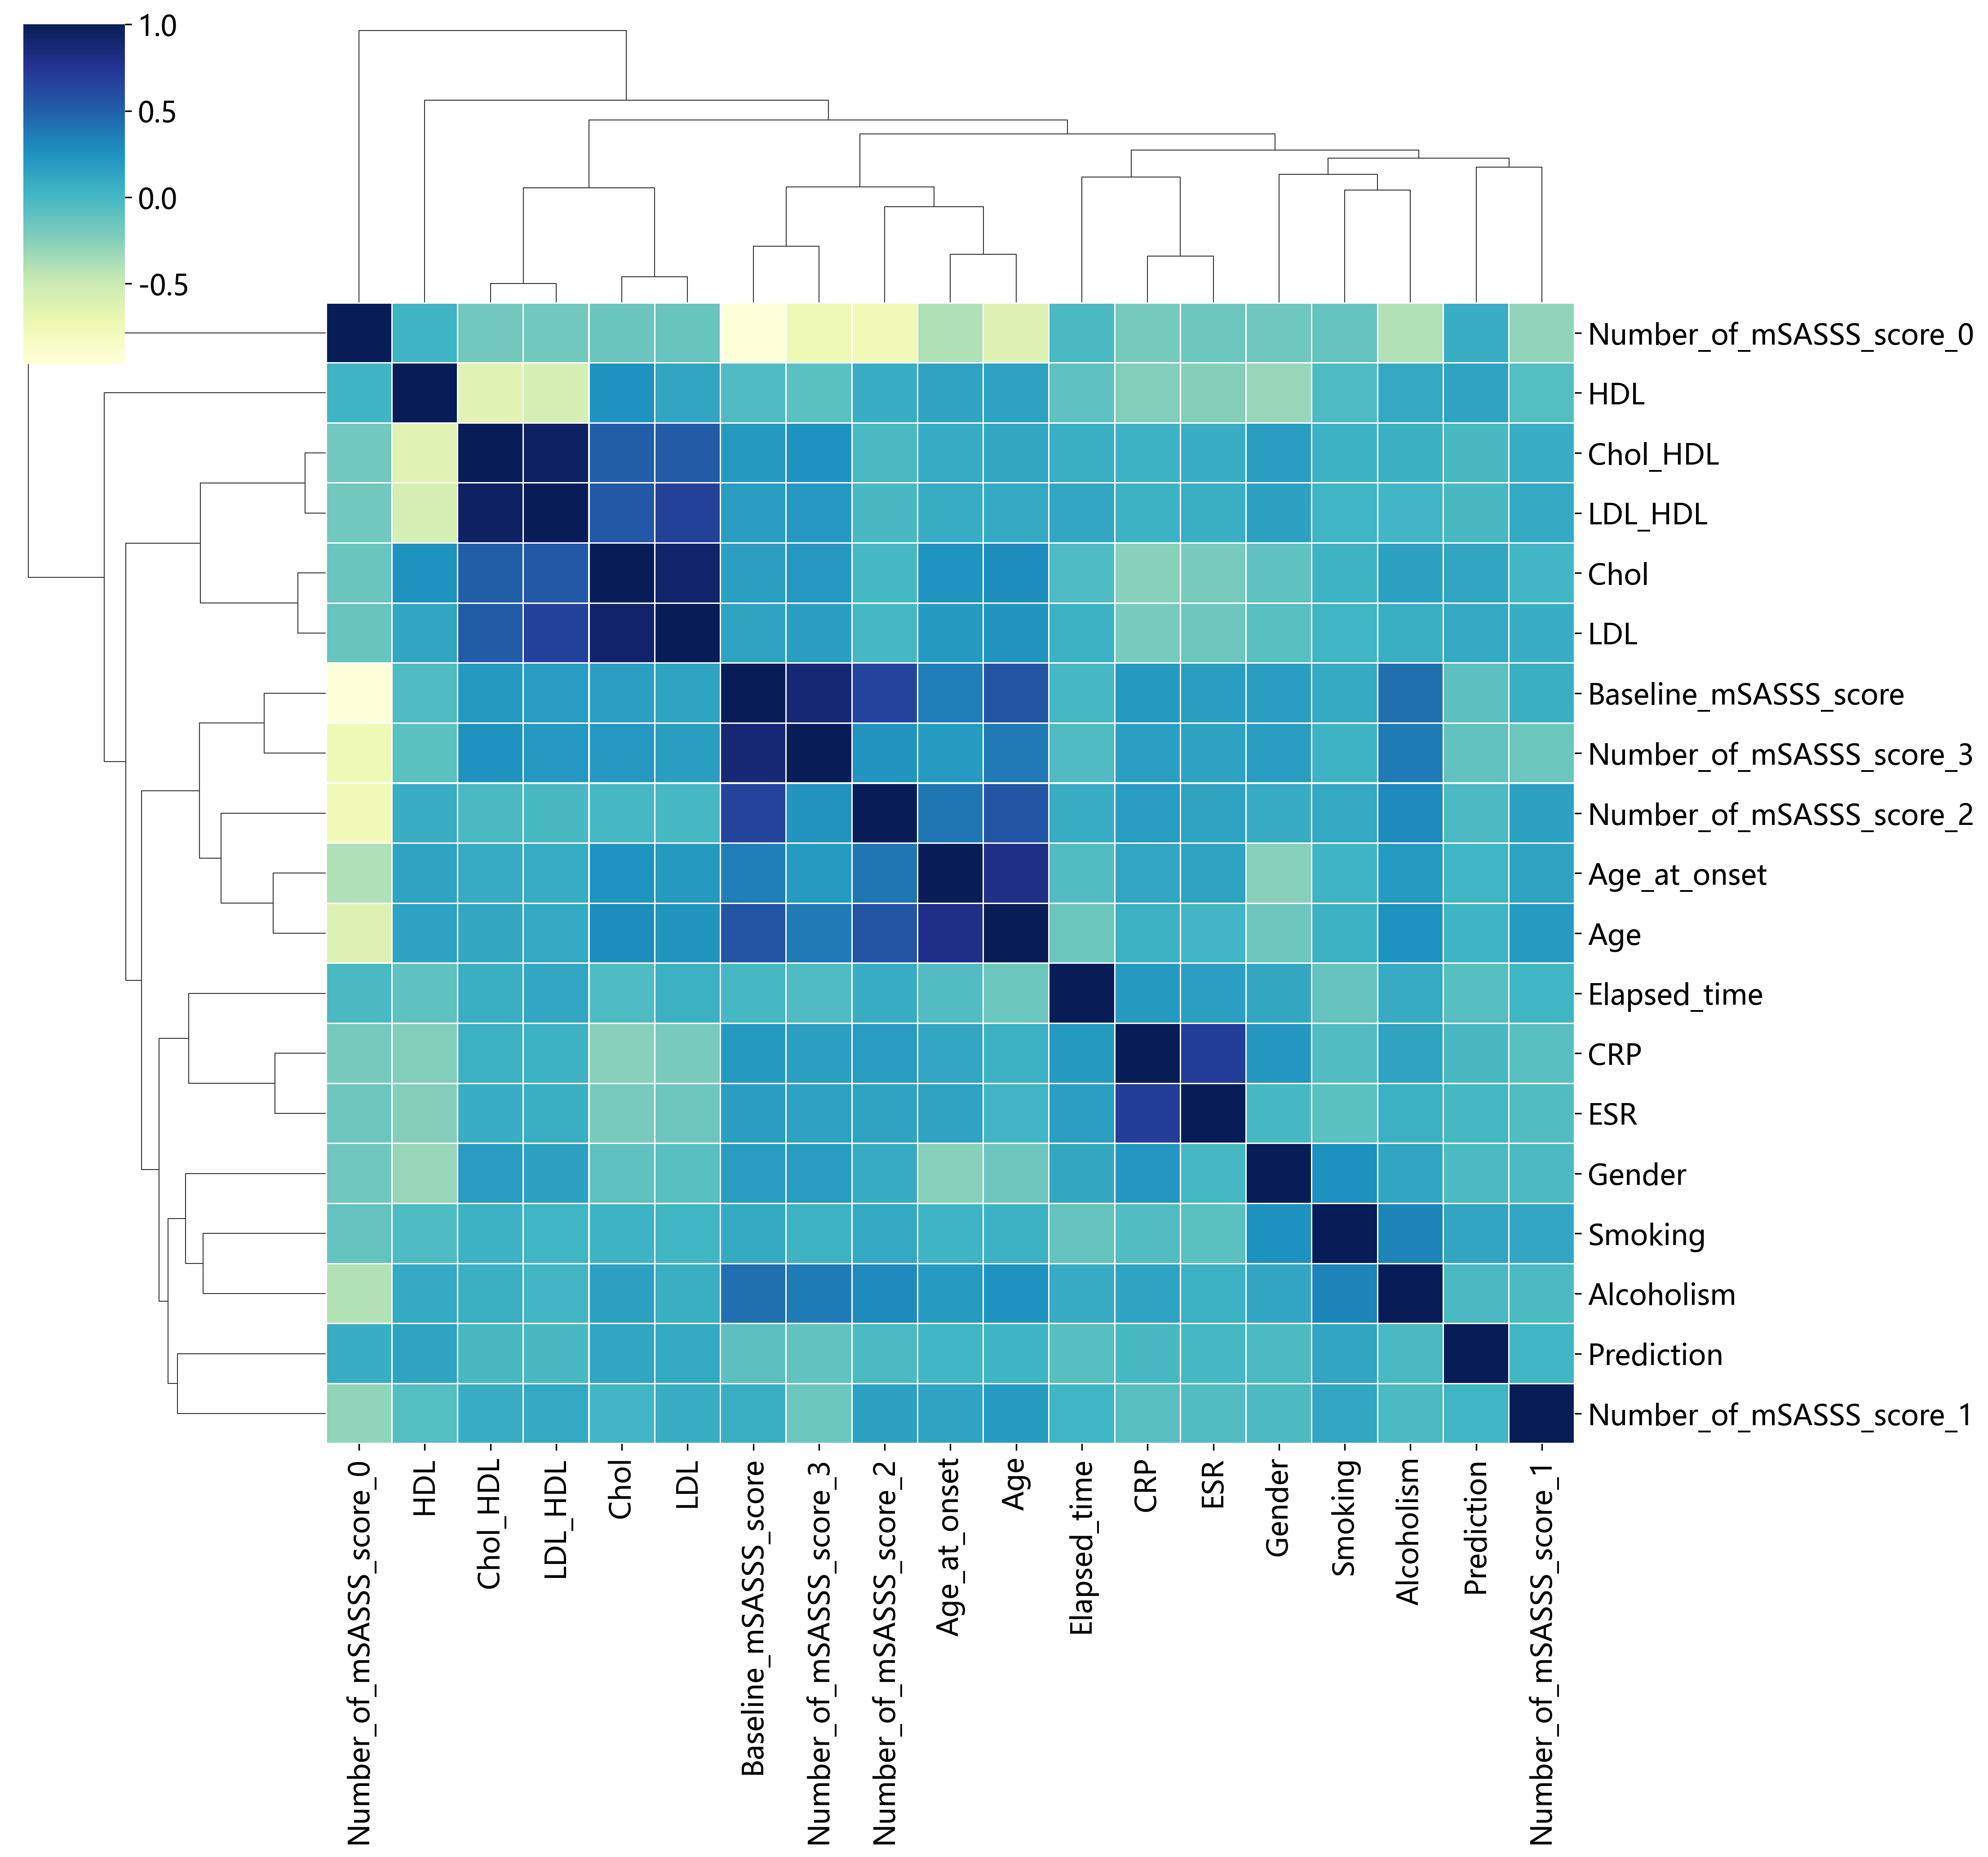

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

if data.shape[1] < 100:
    pp = sns.clustermap(pearson_corr, linewidths=.5, figsize=(15.0, 14.0), cmap='YlGnBu')
    plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)
    plt.savefig(f'img/{task_type}Rad_feature_cluster.svg', bbox_inches = 'tight')

### 特征筛选 -- 相关系数

根据相关系数，对于相关性比较高的特征（一般文献取corr>0.9），两者保留其一。

```python
def select_feature(corr, threshold: float = 0.9, keep: int = 1, topn=10, verbose=False):
    """
    * corr, 相关系数矩阵。
    * threshold，筛选的相关系数的阈值，大于阈值的两者保留其一（可以根据keep修改，可以是其二...）。默认阈值为0.9
    * keep，可以选择大于相关系数，保留几个，默认只保留一个。
    * topn, 每次去掉多少重复特征。
    * verbose，是否打印日志
    """
```

In [13]:
# 特征筛选视频
onekey_show('传统组学任务|特征筛选')

[2026-02-27 19:41:59 - Manager.py: 159]	INFO	播放视频功能已经设置成：Disable！


In [14]:
import math
from onekey_algo.custom.components.comp1 import select_feature, select_feature_mrmr

sel_feature = select_feature(pearson_corr, threshold=0.9, topn=2048, verbose=False)
# sel_feature = select_feature_mrmr(sub_data[sel_feature + labels], num_features=32)
sel_feature += labels + [group_info]
sel_feature

['Prediction',
 'HDL',
 'CRP',
 'ESR',
 'Elapsed_time',
 'Age_at_onset',
 'Age',
 'Baseline_mSASSS_score',
 'Number_of_mSASSS_score_3',
 'Number_of_mSASSS_score_2',
 'Smoking',
 'LDL',
 'LDL_HDL',
 'Number_of_mSASSS_score_1',
 'Gender',
 'Alcoholism',
 'label',
 'group']

### 过滤特征

通过`sel_feature`过滤出筛选出来的特征。

In [15]:
sel_data = data[sel_feature]
sel_data

,Prediction,HDL,CRP,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Number_of_mSASSS_score_3,Number_of_mSASSS_score_2,Smoking,LDL,LDL_HDL,Number_of_mSASSS_score_1,Gender,Alcoholism,label,group
170,-1.398,0.914,-0.629,-1.032,-1.029,-0.308,-0.774,-0.732,-0.407,-0.728,1.180,-2.768,-2.222,-0.690,0.455,-0.455,0.000,test
171,-2.364,2.205,-0.629,-1.032,-0.585,0.636,0.496,1.837,2.033,0.689,-0.843,-0.827,-1.417,-0.690,0.455,-0.455,1.099,test
173,1.095,0.327,-0.505,0.019,-0.644,2.697,2.083,1.944,2.033,0.925,1.180,-0.053,-0.376,-0.690,0.455,2.183,1.792,test
175,0.828,0.757,-0.629,-1.032,-0.733,-0.394,-0.774,-0.304,-0.407,0.216,1.180,0.775,-0.089,-0.690,0.455,-0.455,1.504,test
178,0.235,-1.746,-0.629,-0.876,-0.763,0.293,-0.218,-0.732,-0.407,-0.728,1.180,-1.329,0.154,-0.690,0.455,-0.455,1.504,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,1.159,-0.338,3.065,2.668,-0.674,0.293,1.210,1.141,1.220,0.453,-0.843,-1.221,-0.871,-0.235,0.455,-0.455,0.693,val
276,0.155,-1.159,4.695,2.201,0.805,0.293,0.099,-0.732,-0.407,-0.728,-0.843,0.259,1.183,-0.690,0.455,-0.455,1.792,val
279,-0.581,-0.064,-0.165,-0.331,-1.029,-1.081,-0.060,2.800,3.253,0.689,1.180,1.101,0.697,-0.690,0.455,-0.455,1.099,val
280,-0.336,-0.768,0.021,-0.253,-0.289,0.465,-0.060,-0.357,-0.407,-0.256,-0.843,0.978,1.345,0.219,0.455,-0.455,1.705,val


### 样本可视化

根据特征和label信息，将rad features降维到2维，看不同的label样本在二维空间的分布。

**注意**：由于特征空间维度极高，降维难免会有损失，所以二维的可视化仅供参考。

目前支持的:

| **降维方法** | **Method名称**                                                 |
| ------------ | ------------------------------------------------------------ |
| LLE      | Standard LLE, Modified LLE                                   |
| PCA      | t-SNE, NCA                                                      |
| SVD      | Truncated SVD                                              |
| Model Based      | Random projection, Isomap, MDS, Random Trees,Spectral       |

In [16]:
from onekey_algo.custom.components.comp1 import analysis_features
# analysis_features(data[sel_feature[:-2]], data[labels[0]], methods='t-SNE', legend=class_mapping.keys())

## 构建数据

将样本的训练数据X与监督信息y分离出来，并且对训练数据进行划分，一般的划分原则为80%-20%

In [17]:
import numpy as np
import onekey_algo.custom.components as okcomp
from collections import OrderedDict
n_classes = 2
train_data = sel_data[(sel_data[group_info] == 'train')]
train_ids = ids[train_data.index]
train_data = train_data.reset_index()
train_data = train_data.drop('index', axis=1)
y_data = train_data[labels]
X_data = train_data.drop(labels + [group_info], axis=1)

subsets = [s for s in get_param_in_cwd('subsets') if s != 'train']
val_datasets = OrderedDict()
for subset in subsets:
    val_data = sel_data[sel_data[group_info] == subset]
    val_ids = ids[val_data.index]
    val_data = val_data.reset_index()
    val_data = val_data.drop('index', axis=1)
    y_val_data = val_data[labels]
    X_val_data = val_data.drop(labels + [group_info], axis=1)
    val_datasets[subset] = [X_val_data, y_val_data, val_ids]

y_all_data = sel_data[labels]
X_all_data = sel_data.drop(labels + [group_info], axis=1)

column_names = X_data.columns
print(f"训练集样本数：{X_data.shape}，", '，'.join([f"{subset}样本数：{d_[0].shape}" for subset, d_ in val_datasets.items()]))

训练集样本数：(168, 16)， val样本数：(71, 16)，test样本数：(49, 16)


### Lasso

初始化Lasso模型，alpha为惩罚系数。具体的参数文档可以参考：[文档](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html?highlight=lasso#sklearn.linear_model.Lasso)

### 交叉验证

不同Lambda下的，特征的的权重大小。
```python
def lasso_cv_coefs(X_data, y_data, points=50, column_names: List[str] = None, **kwargs):
    """

    Args:
        X_data: 训练数据
        y_data: 监督数据
        points: 打印多少个点。默认50
        column_names: 列名，默认为None，当选择的数据很多的时候，建议不要添加此参数
        **kwargs: 其他用于打印控制的参数。

    """
 ```

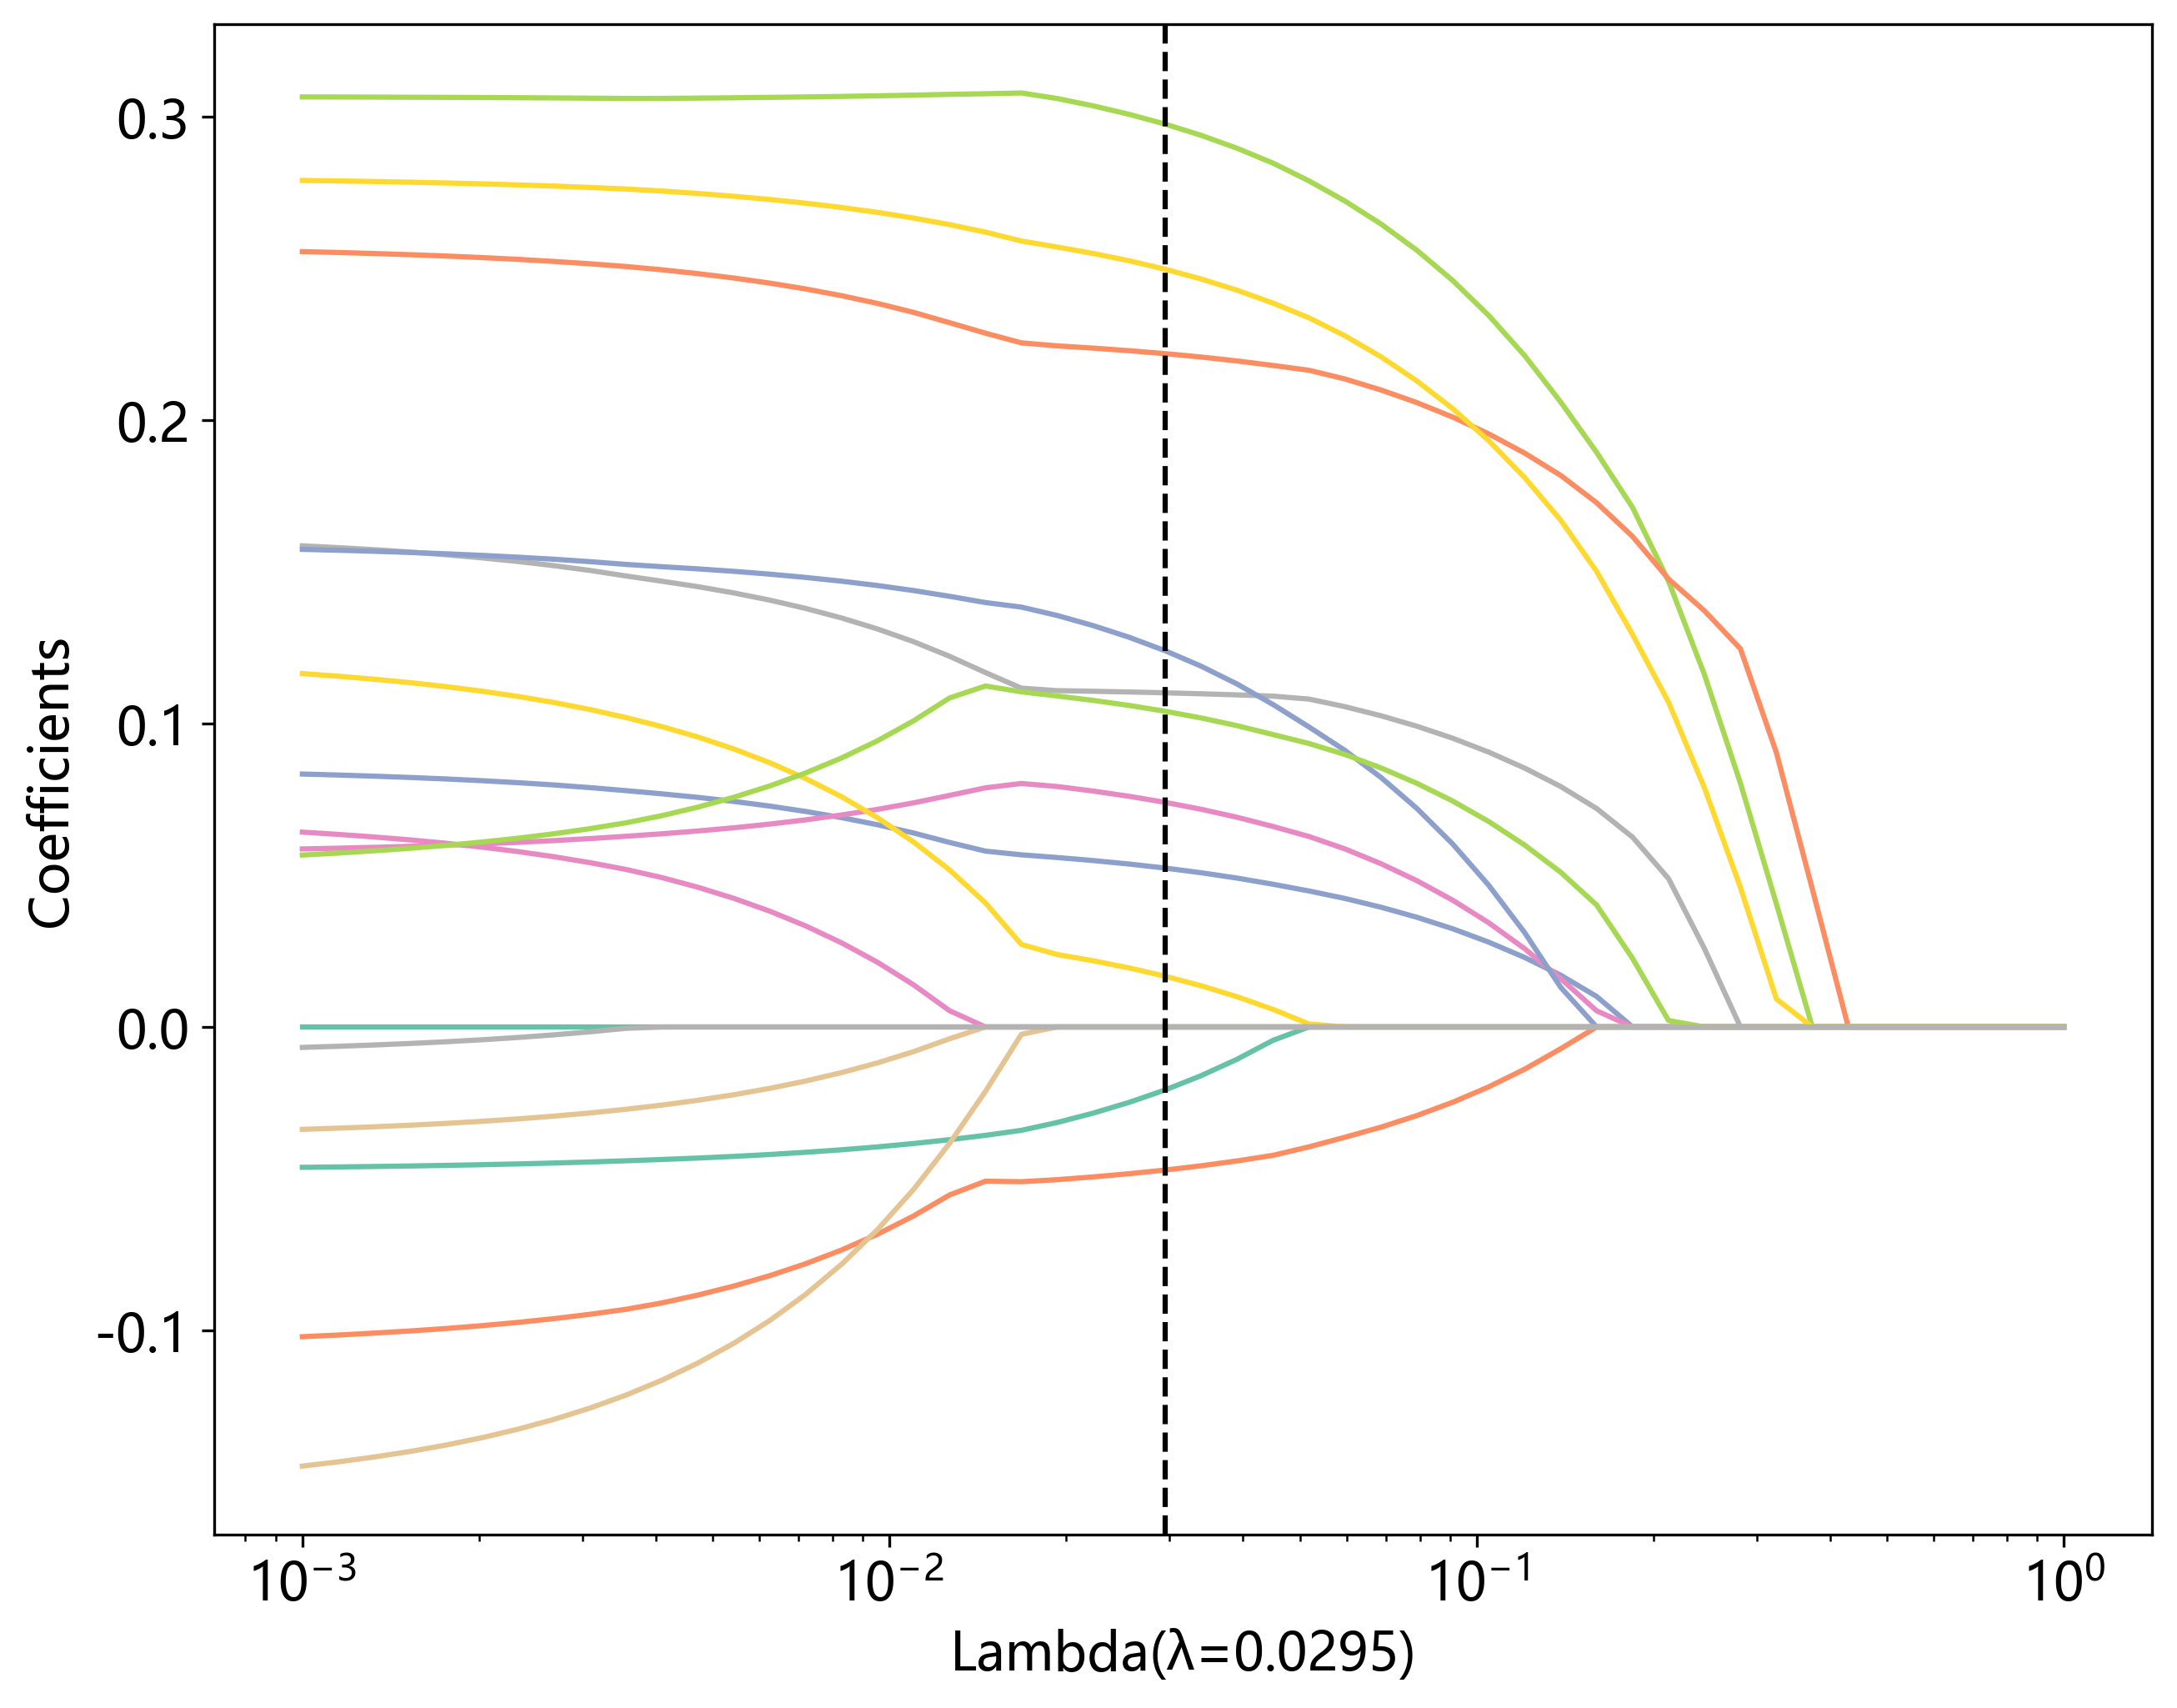

In [18]:
alpha = okcomp.comp1.lasso_cv_coefs(X_data, y_data, column_names=None, ensure_lastn=-20)
plt.savefig(f'img/{task_type}_feature_lasso.svg', bbox_inches = 'tight')

### 模型效能

```python
def lasso_cv_efficiency(X_data, y_data, points=50, **kwargs):
    """

    Args:
        Xdata: 训练数据
        ydata: 测试数据
        points: 打印的数据密度
        **kwargs: 其他的图像样式
            # 数据点标记, fmt="o"
            # 数据点大小, ms=3
            # 数据点颜色, mfc="r"
            # 数据点边缘颜色, mec="r"
            # 误差棒颜色, ecolor="b"
            # 误差棒线宽, elinewidth=2
            # 误差棒边界线长度, capsize=2
            # 误差棒边界厚度, capthick=1
    Returns:
    """
 ```

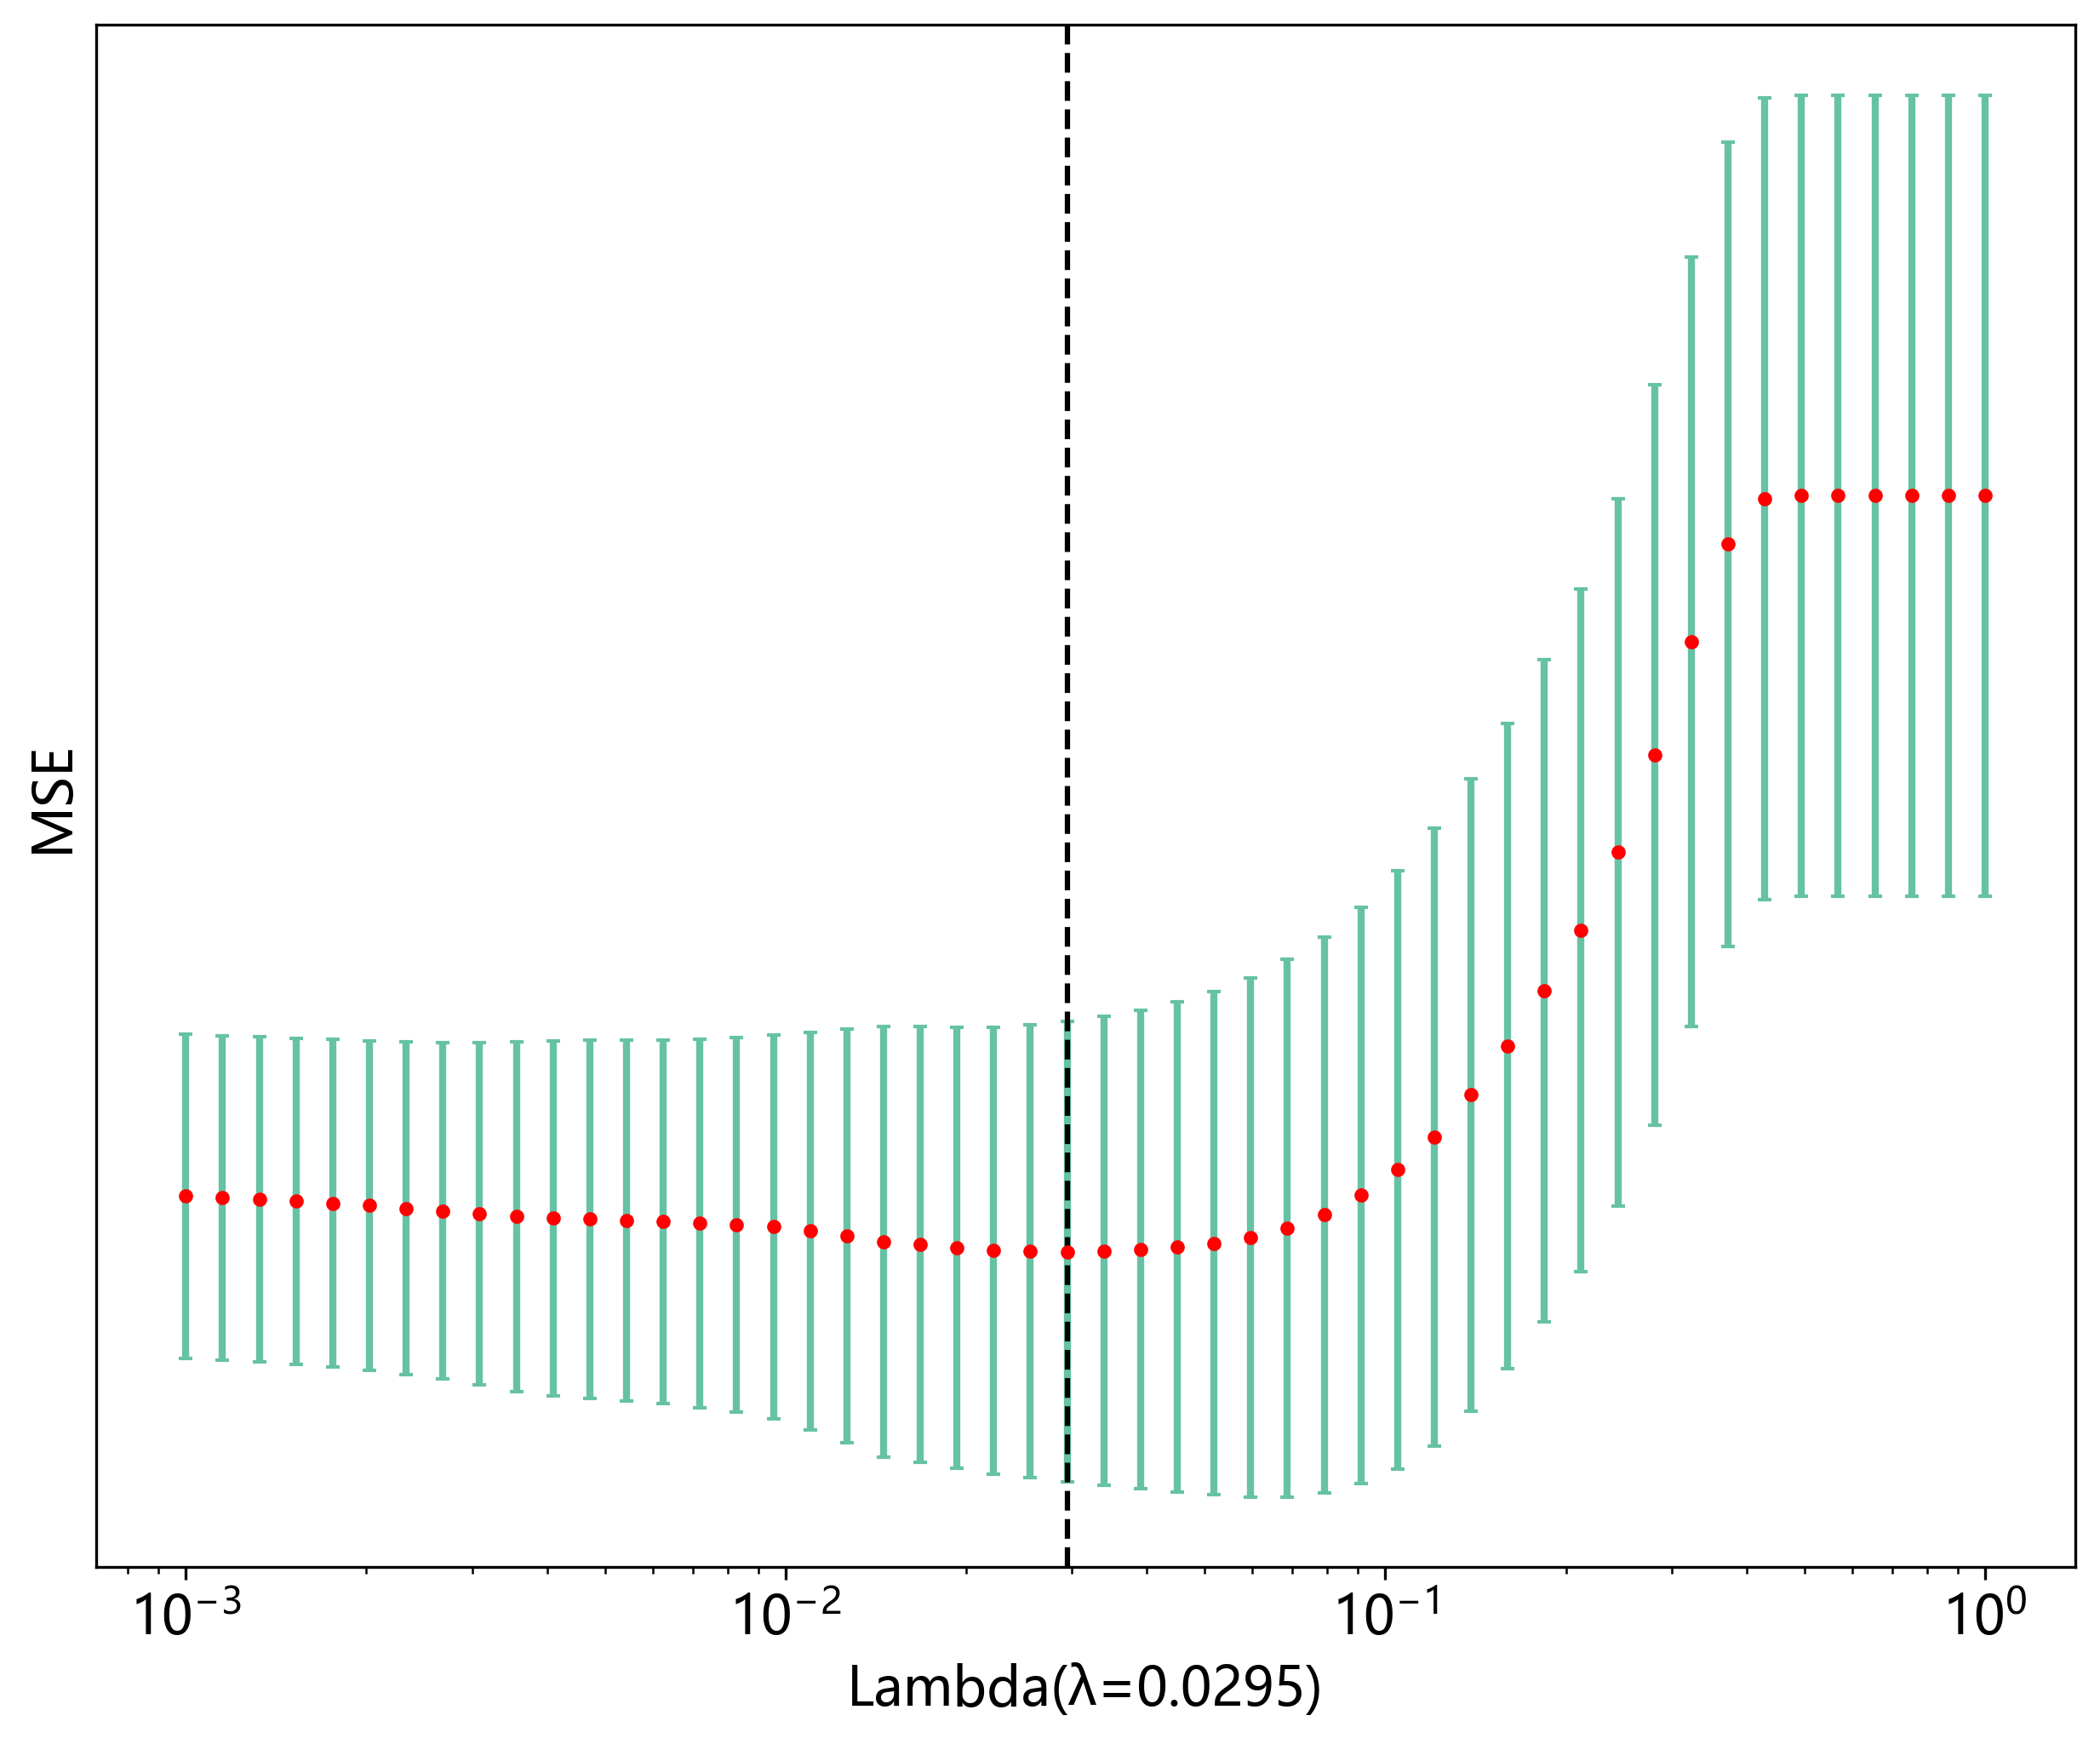

In [19]:
okcomp.comp1.lasso_cv_efficiency(X_data, y_data, points=50, ensure_lastn=-20, y_major_locator=5)
plt.savefig(f'img/{task_type}_feature_mse.svg', bbox_inches = 'tight')

### 惩罚系数

使用交叉验证的惩罚系数作为模型训练的基础。

In [20]:
from sklearn import linear_model

models = []
for label in labels:
    clf = linear_model.Lasso(alpha=alpha)
    clf.fit(X_data, y_data[label])
    models.append(clf)

### 特征筛选

筛选出其中coef > 0的特征。并且打印出相应的公式。

In [21]:
COEF_THRESHOLD = 1e-6 # 筛选的特征阈值
scores = []
selected_features = []
for label, model in zip(labels, models):
    feat_coef = [(feat_name, coef) for feat_name, coef in zip(column_names, model.coef_) 
                 if COEF_THRESHOLD is None or abs(coef) > COEF_THRESHOLD]
    selected_features.append([feat for feat, _ in feat_coef])
    formula = ' '.join([f"{coef:+.6f} * {feat_name}" for feat_name, coef in feat_coef])
    score = f"{label} = {model.intercept_} {'+' if formula[0] != '-' else ''} {formula}"
    scores.append(score)
    
print(scores[0])

label = 0.9003449886369048  -0.020757 * Prediction -0.047162 * HDL +0.052341 * CRP +0.074024 * ESR +0.297549 * Elapsed_time +0.016710 * Age_at_onset +0.110121 * Baseline_mSASSS_score +0.221900 * Number_of_mSASSS_score_2 +0.123985 * Smoking +0.104036 * LDL_HDL +0.249709 * Number_of_mSASSS_score_1


### 特征权重

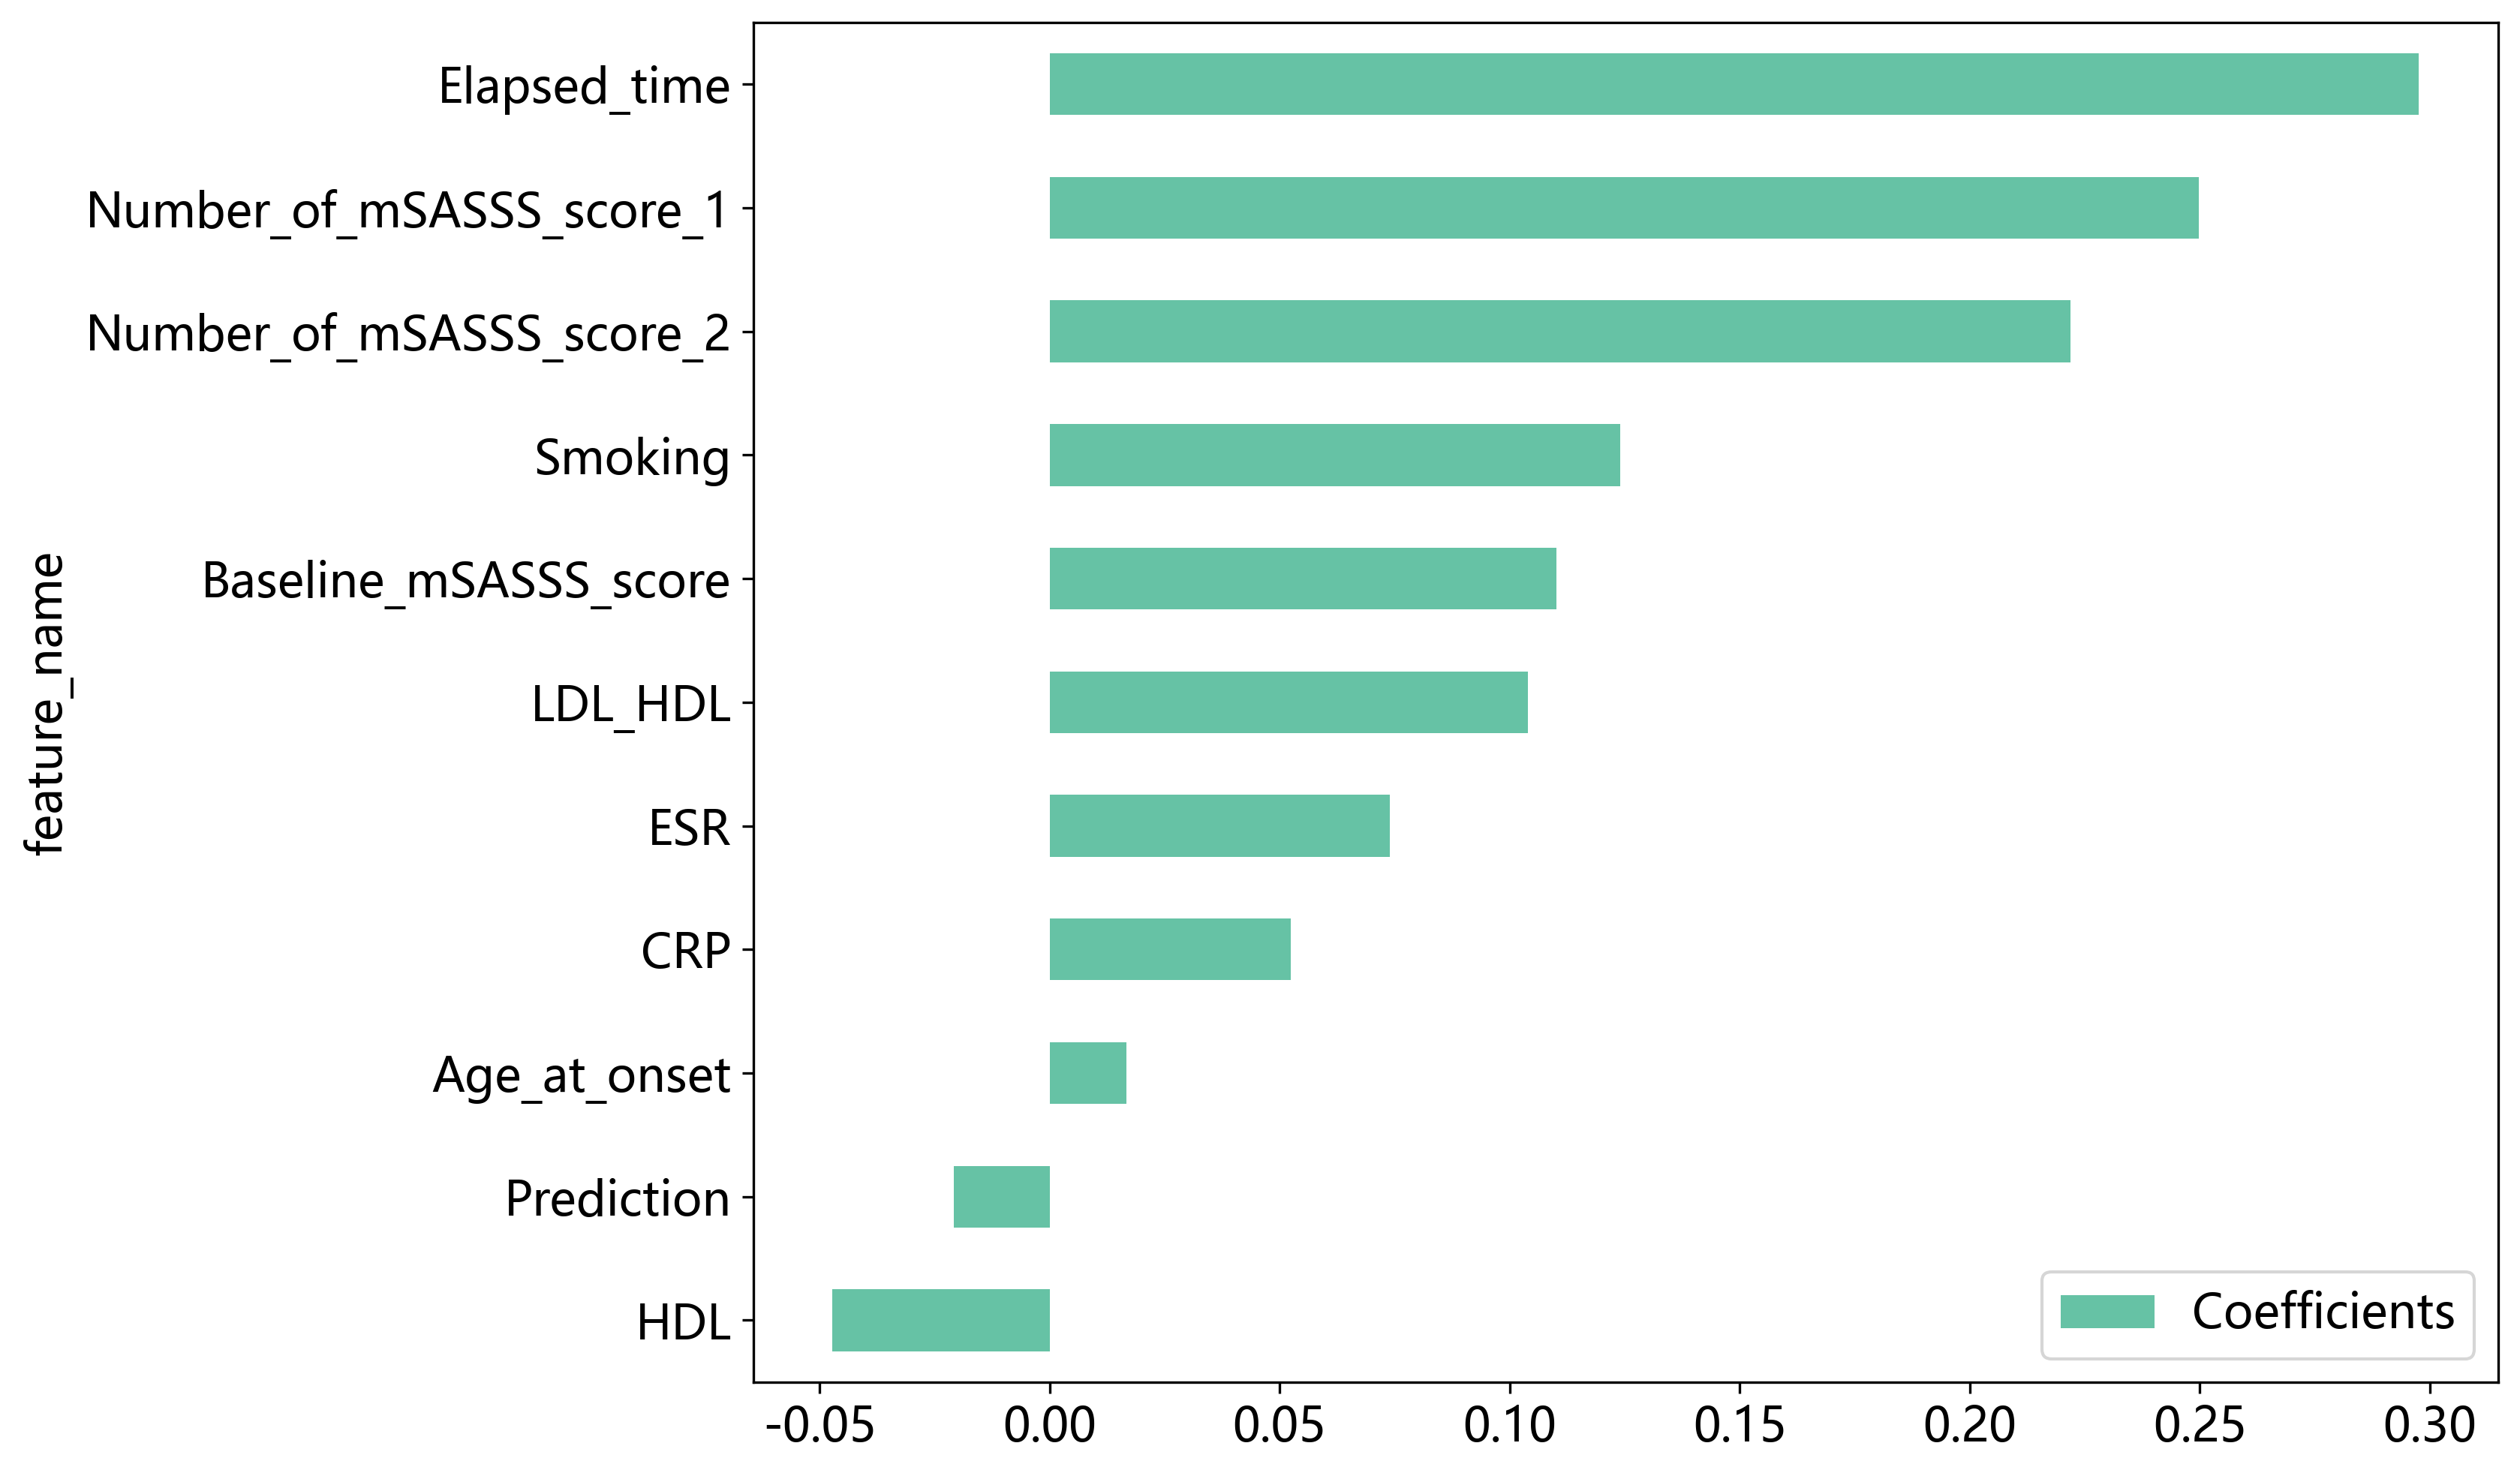

In [22]:
feat_coef = sorted(feat_coef, key=lambda x: x[1])
feat_coef_df = pd.DataFrame(feat_coef, columns=['feature_name', 'Coefficients'])
feat_coef_df.plot(x='feature_name', y='Coefficients', kind='barh')

plt.savefig(f'img/{task_type}_feature_weights.svg', bbox_inches = 'tight')

### 进一步筛选特征

使用Lasso筛选出来的Coefficients比较高的特征作为训练数据。

In [23]:
# X_data = X_data[selected_features[0]]
# for subset in val_datasets:
#     val_datasets[subset][0] = val_datasets[subset][0][selected_features[0]]
# X_data.columns

In [24]:
pd.concat([ids, combined_data[selected_features[0]]], axis=1).to_csv(f'features/{task_type}rad_sel_features.csv', index=False)

## 模型筛选

根据筛选出来的数据，做模型的初步选择。当前主要使用到的是Onekey中的

1. SVM，支持向量机，引用参考。
2. KNN，K紧邻，引用参考。
3. Decision Tree，决策树，引用参考。
4. Random Forests, 随机森林，引用参考。
5. XGBoost, bosting方法。引用参考。
6. LightGBM, bosting方法，引用参考。

In [25]:
import joblib
from onekey_algo.custom.components.comp1 import plot_feature_importance
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

model_names = get_param_in_cwd('ml_models')
models = okcomp.comp1.create_reg_model(model_names)
# models['LR'] = LogisticRegression(penalty='none', max_iter=100)
# models['RandomForest'] = RandomForestClassifier(n_estimators=40, max_depth=4, min_samples_split=2, random_state=0)
# models['XGBoost'] = XGBClassifier(n_estimators=15, objective='binary:logistic', max_depth=2, min_child_weight=1.2,
#                                   use_label_encoder=False, eval_metric='error')
# models['LightGBM'] = LGBMClassifier(n_estimators=24,  max_depth=2, min_child_weight=0.5,)
    
model_names = list(models.keys())

### 交叉验证

`n_trails`指定随机次数，每次采用的是80%训练，随机20%进行测试，找到最好的模型，以及对应的最好的数据划分。


```python
def get_bst_split(X_data: pd.DataFrame, y_data: pd.DataFrame,
            models: dict, test_size=0.2, metric_fn=accuracy_score, n_trails=10,
            cv: bool = False, shuffle: bool = False, metric_cut_off: float = None, random_state=None):
    """
    寻找数据集中最好的数据划分。
    Args:
        X_data: 训练数据
        y_data: 监督数据
        models: 模型名称，Dict类型、
        test_size: 测试集比例，只有当cv=False时生效
        metric_fn: 评价模型好坏的函数，默认准确率，可选roc_auc_score。
        n_trails: 尝试多少次寻找最佳数据集划分。
        cv: 是否是交叉验证，默认是False，当为True时，n_trails为交叉验证的n_fold
        shuffle: 是否进行随机打乱
        metric_cut_off: 当metric_fn的值达到多少时进行截断。
        random_state: 随机种子

    Returns: {'max_idx': max_idx, "max_model": max_model, "max_metric": max_metric, "results": results}

    """
```

**注意：这里采用了【挑数据】，如果想要严谨，请修改`n_trails=1`。**

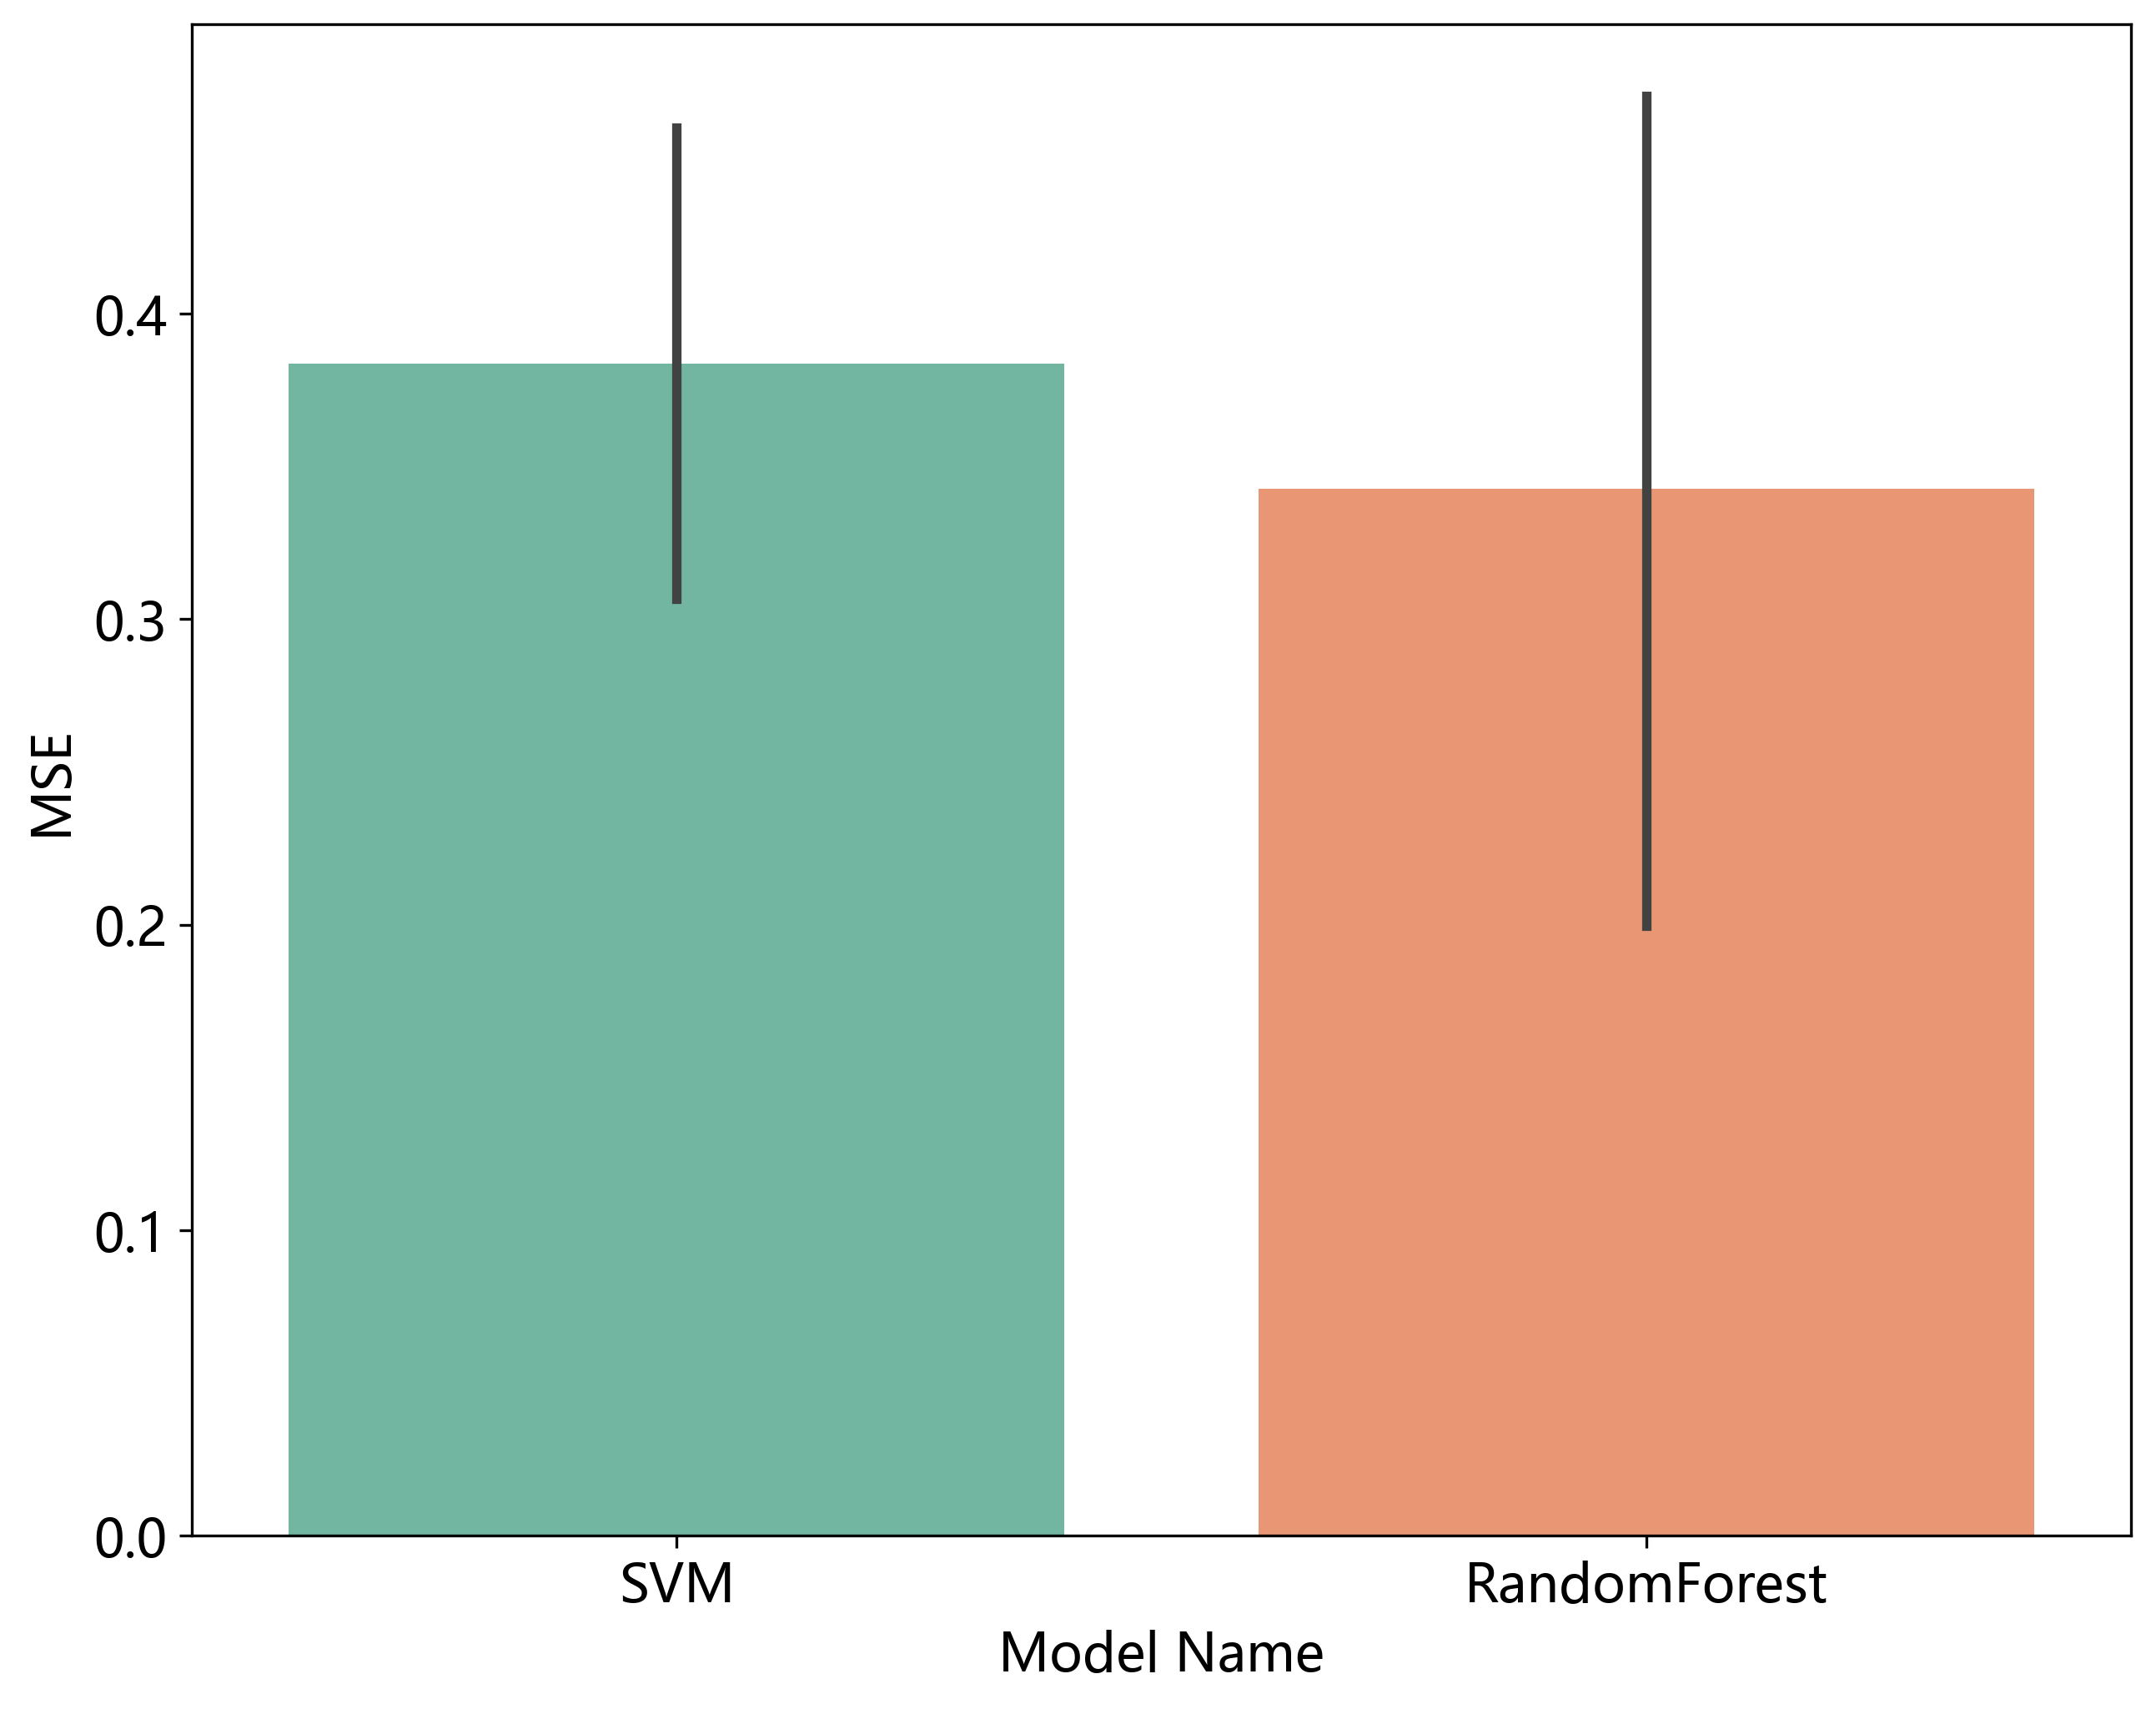

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

# 随机使用n_trails次数据划分，找到最好的一次划分方法，并且保存在results中。
results = okcomp.comp1.get_bst_split(X_data, y_data, models, test_size=0.2, metric_fn=mean_squared_error, n_trails=5, random_state=0)
# _, (X_train_sel, X_test_sel, y_train_sel, y_test_sel) = results['results'][results['max_idx']]
trails, _ = zip(*results['results'])
cv_results = pd.DataFrame(trails, columns=model_names)
# 可视化每个模型在不同的数据划分中的效果。
sns.barplot(data=cv_results)
plt.ylabel('MSE')
plt.xlabel('Model Name')
# plt.xticks(rotation=90)
# plt.ylim(0.5,)
plt.savefig(f'img/{task_type}_model_cv.svg', bbox_inches = 'tight')

## 模型筛选

使用最好的数据划分，进行后续的模型研究。

**注意**: 一般情况下论文使用的是随机划分的数据，但也有些论文使用【刻意】筛选的数据划分。

In [27]:
# import joblib
# from onekey_algo.custom.components.comp1 import plot_feature_importance, smote_resample
# from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
# from sklearn.neural_network import MLPRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from sklearn.svm import SVR
# from sklearn.metrics import accuracy_score
# from sklearn.preprocessing import OneHotEncoder
# from onekey_algo.custom.components.delong import calc_95_CI
# from onekey_algo.custom.components.metrics import analysis_pred_binary

# os.makedirs('models', exist_ok=True)
# sel_model = 'SVM'
# maxi = 100
# for p in range(1, 100):
#     for md in range(1, 5):
#         targets = []
#         print(p, md)
#         for l in labels:
#             new_models = okcomp.comp1.create_clf_model([sel_model])
#             if sel_model == 'SVM':
#                 new_models['SVM'] = SVR(max_iter=p, C=md)
#             if sel_model == 'RandomForest':
#                 new_models['RandomForest'] = RandomForestRegressor(n_estimators=p, max_depth=md, min_samples_split=2, random_state=0)
#             elif sel_model == 'ExtraTrees':
#                 new_models['ExtraTrees'] = ExtraTreesRegressor(n_estimators=p, max_depth=md, min_samples_split=2, random_state=0)
#             elif sel_model == 'LightGBM':
#                 new_models['LightGBM'] = LGBMRegressor(n_estimators=p, max_depth=md, random_state=0)
#             elif sel_model == 'XGBoost':
#                 new_models['XGBoost'] = XGBRegressor(n_estimators=p, objective='reg:squarederror', max_depth=md, min_child_weight=.2,
#                                                       use_label_encoder=False, eval_metric='rmse')            
#             model_names = list(new_models.keys())
#             new_models = list(new_models.values())
#             for mn, m in zip(model_names, new_models):        
#                 X_train_sel, y_train_sel = X_data, y_data
# #                 X_train_sel, y_train_sel = smote_resample(X_train_sel, y_train_sel)
#                 m.fit(X_train_sel, y_train_sel[l])
#                 # 保存训练的模型
#         #         joblib.dump(m, f'models/{task_type}_{mn}_{l}.pkl') 
#                 # 输出模型特征重要性，只针对高级树模型有用
#         #         plot_feature_importance(m, selected_features[0], save_dir='img', prefix=f"{task_type}_")
#             targets.append(new_models)


#         metric = []
#         pred_sel_idx = []
#         X_train_sel, y_train_sel = X_data, y_data
#         predictions = [[(model.predict(X_train_sel), 
#                          [(model.predict(X_val_sel), y_val_sel) for X_val_sel, y_val_sel, _ in val_datasets.values()])  
#                         for model in target] for label, target in zip(labels, targets)]

#         for label, prediction in zip(labels, predictions):
#             for mname, (train_pred, val_preds) in zip(model_names, prediction):
#                 # 计算训练集指数
#                 metric.append((mname, mean_squared_error(y_train_sel[label], train_pred),
#                                mean_absolute_percentage_error(y_train_sel[label], train_pred), f"train"))
#                 for subset, (val_pred, y_val_sel) in zip(val_datasets.keys(), val_preds):
#                     metric.append((mname, mean_squared_error(y_val_sel[label], val_pred), 
#                                    mean_absolute_percentage_error(y_val_sel[label], val_pred), f"{subset}"))
#         metric = pd.DataFrame(metric, index=None, columns=['model_name', 'MSE', 'MAPE', 'Cohort'])
#         tauc = float(metric[(metric['model_name'] == sel_model) & (metric['Cohort'] == 'test')]['MSE'])
#         if tauc < maxi or tauc < 0.01:
#             maxi = tauc
#             print('-----------> ', maxi, p, md)
#         display(metric)

In [28]:
import joblib
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from onekey_algo.custom.components.comp1 import plot_feature_importance, smote_resample

targets = []
os.makedirs('models', exist_ok=True)
class_weight = None# {0:5, 1:5, 2:1}
for l in labels:
    new_models = okcomp.comp1.create_reg_model(model_names)
    new_models['SVM'] = SVR(max_iter=51, C=3)
    new_models['RandomForest'] = RandomForestRegressor(n_estimators=8, max_depth=4,
                                                           min_samples_split=2, random_state=0)
#     new_models['ExtraTrees'] = ExtraTreesRegressor(n_estimators=1, max_depth=2,
#                                                        min_samples_split=2, random_state=0)
#     new_models['LightGBM'] = LGBMRegressor(n_estimators=2, max_depth=1, objective='regression')
#     new_models['XGBoost'] = XGBRegressor(n_estimators=1, max_depth=2, objective='reg:squarederror',
#                                              eval_metric='rmse')
    model_names = list(new_models.keys())
    new_models = list(new_models.values())
    for mn, m in zip(model_names, new_models):        
        X_train_sel, y_train_sel = X_data, y_data
#         X_train_sel, y_train_sel = smote_resample(X_train_sel, y_train_sel)
        m.fit(X_train_sel, y_train_sel[l])
        # 保存训练的模型
#         joblib.dump(m, f'models/{task_type}_{mn}_{l}.pkl') 
        # 输出模型特征重要性，只针对高级树模型有用
#         plot_feature_importance(m, selected_features[0], save_dir='img', prefix=f"{task_type}_")
    targets.append(new_models)

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from onekey_algo.custom.components.delong import calc_95_CI
from onekey_algo.custom.components.metrics import analysis_pred_binary

metric = []
pred_sel_idx = []
X_train_sel, y_train_sel = X_data, y_data
predictions = [[(model.predict(X_train_sel), 
                 [(model.predict(X_val_sel), y_val_sel) for X_val_sel, y_val_sel, _ in val_datasets.values()])  
                for model in target] for label, target in zip(labels, targets)]

for label, prediction in zip(labels, predictions):
    for mname, (train_pred, val_preds) in zip(model_names, prediction):
        # 计算训练集指数
        metric.append((mname, mean_squared_error(y_train_sel[label], train_pred),
                       mean_absolute_error(y_train_sel[label], train_pred), f"train"))
        for subset, (val_pred, y_val_sel) in zip(val_datasets.keys(), val_preds):
            metric.append((mname, mean_squared_error(y_val_sel[label], val_pred), 
                           mean_absolute_error(y_val_sel[label], val_pred), f"{subset}"))
metric = pd.DataFrame(metric, index=None, columns=['model_name', 'MSE', 'MAPE', 'Cohort'])
metric.to_csv(f'results/{task_type}_regression.csv', index=False)
metric

,model_name,MSE,MAPE,Cohort
0,SVM,0.155,0.323,train
1,SVM,0.481,0.516,val
2,SVM,0.307,0.437,test
3,RandomForest,0.146,0.270,train
4,RandomForest,0.411,0.438,val
5,RandomForest,0.293,0.390,test


### 绘制曲线

绘制的不同模型的准确率柱状图和折线图曲线。

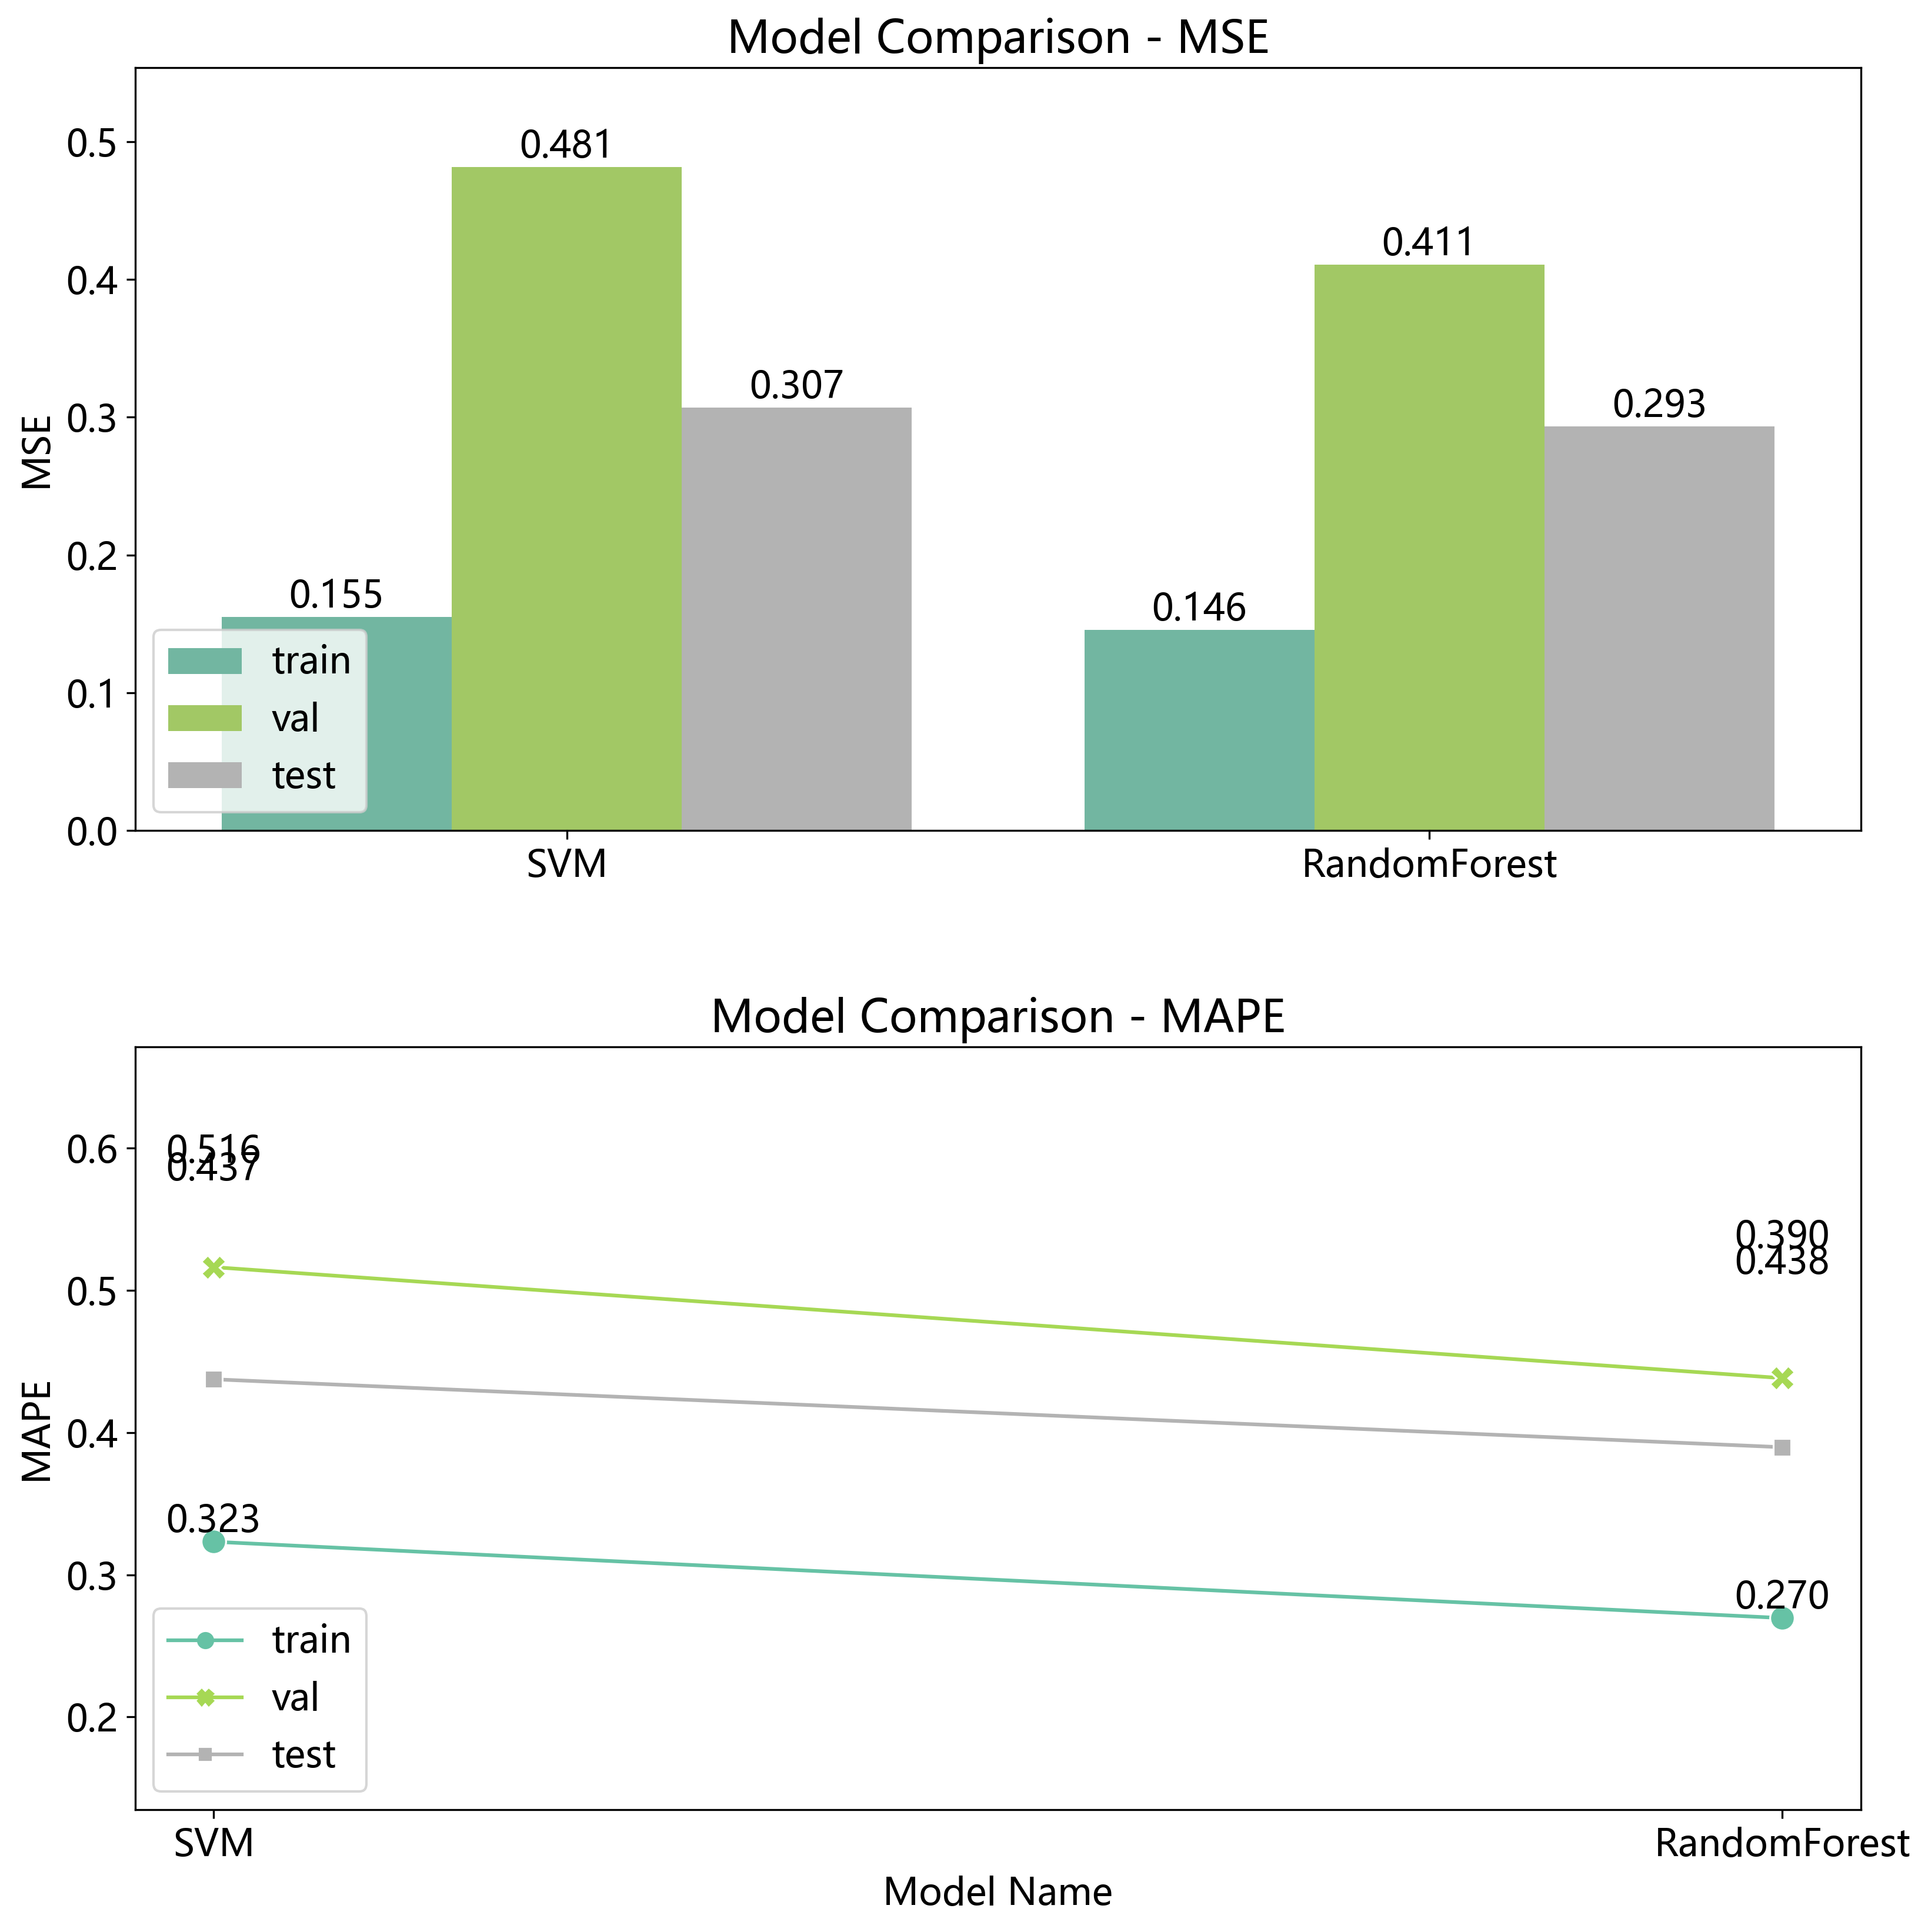

In [30]:
import seaborn as sns
from onekey_algo.custom.components.comp1 import get_colors_from_config

plt.figure(figsize=(12, 12))

# 第一个子图 - MSE柱状图
plt.subplot(211)
ax1 = sns.barplot(x='model_name', y='MSE', data=metric, hue='Cohort', palette=get_colors_from_config(3))
plt.legend(loc=3)
plt.title('Model Comparison - MSE')
plt.ylabel('MSE')
plt.xlabel('')
max_mse = metric['MSE'].max()
plt.ylim(0, max_mse * 1.15)

# 添加数值标签
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height ,
             f'{height:.3f}',
             ha='center', va='bottom')

# 第二个子图 - MAPE折线图
plt.subplot(212)
ax2 = sns.lineplot(x='model_name', y='MAPE', data=metric, hue='Cohort', 
                  style='Cohort', markers=True, dashes=False, palette=get_colors_from_config(3), 
                  markersize=10, )
plt.title('Model Comparison - MAPE')
plt.ylabel('MAPE')
plt.xlabel('Model Name')
max_mape = metric['MAPE'].max()
plt.legend(loc=3)
plt.ylim(metric['MAPE'].min() * 0.5, max_mape * 1.30)

# 添加数值标签
for idx, cohort in enumerate(metric['Cohort'].unique()):
    cohort_data = metric[metric['Cohort'] == cohort]
    for i, row in cohort_data.iterrows():
        ax2.text(row['model_name'], row['MAPE'] + idx / 15, 
                f'{row["MAPE"]:.3f}', 
                ha='center', va='bottom')

plt.tight_layout(pad=3.0)
plt.legend(loc=3)
plt.savefig(f'img/{task_type}_model_mse.svg', bbox_inches='tight')
plt.show()

## 保存模型结果

可以把模型预测的标签结果以及每个类别的概率都保存下来。

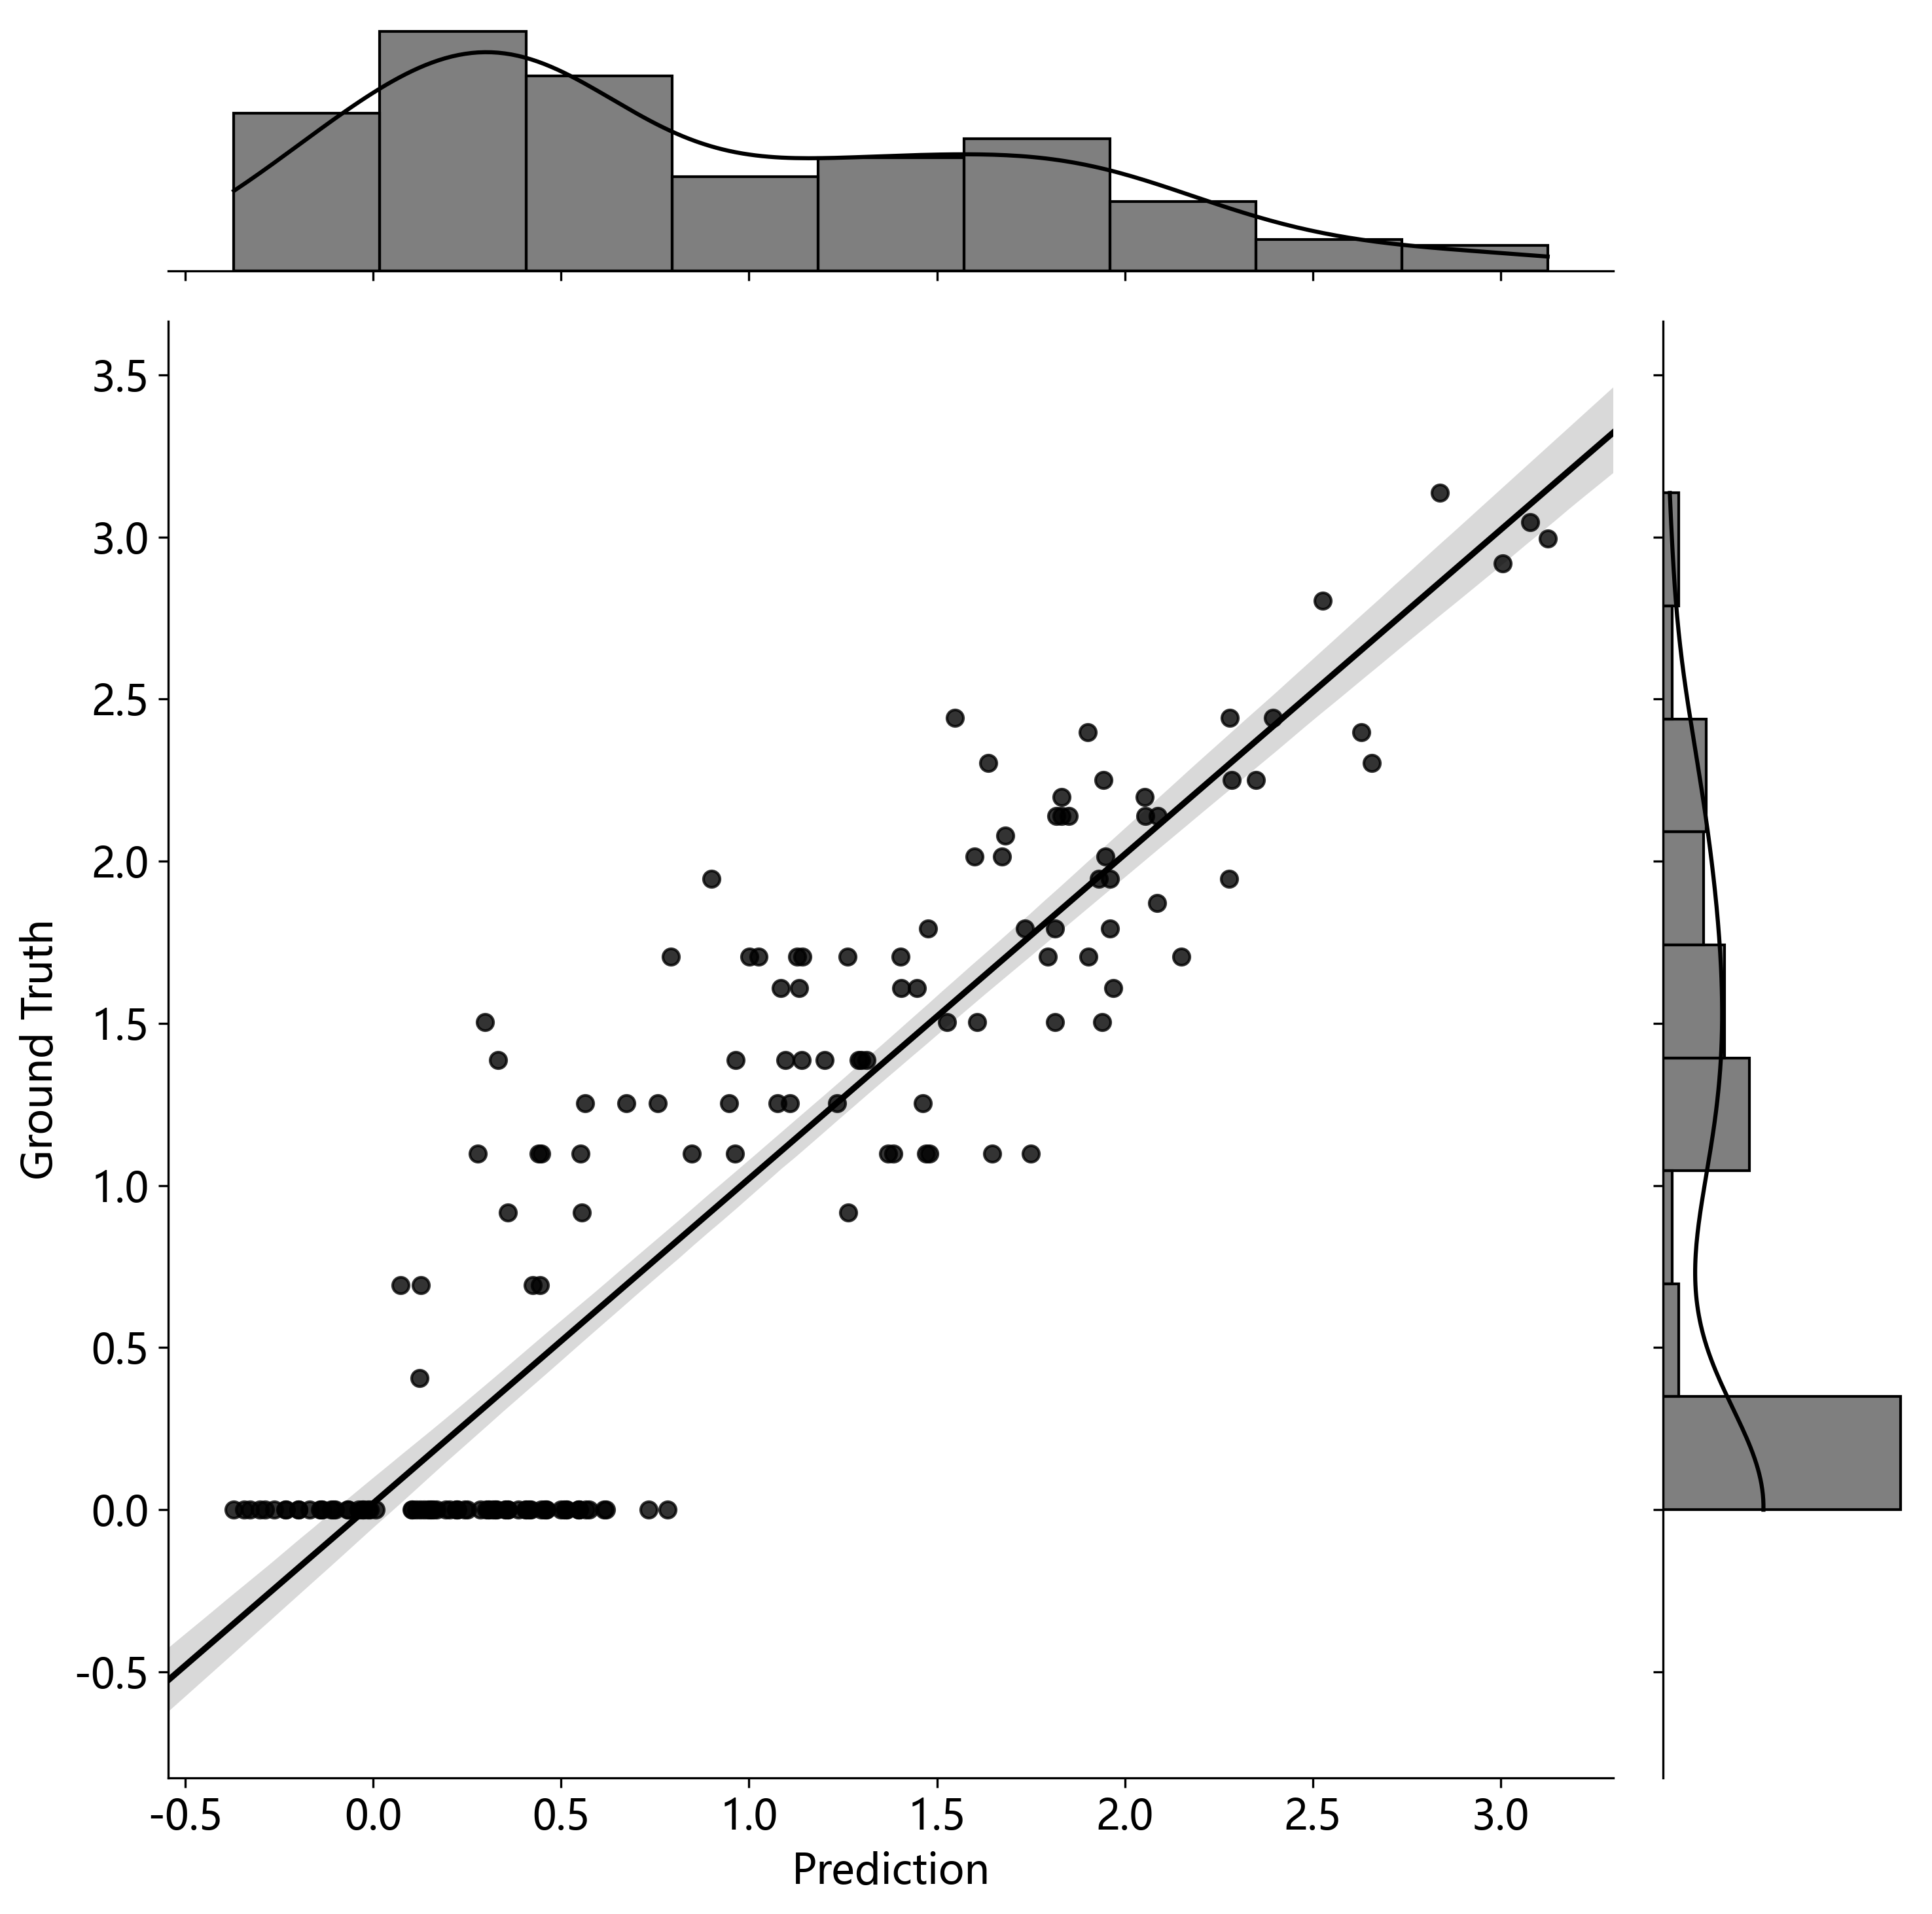

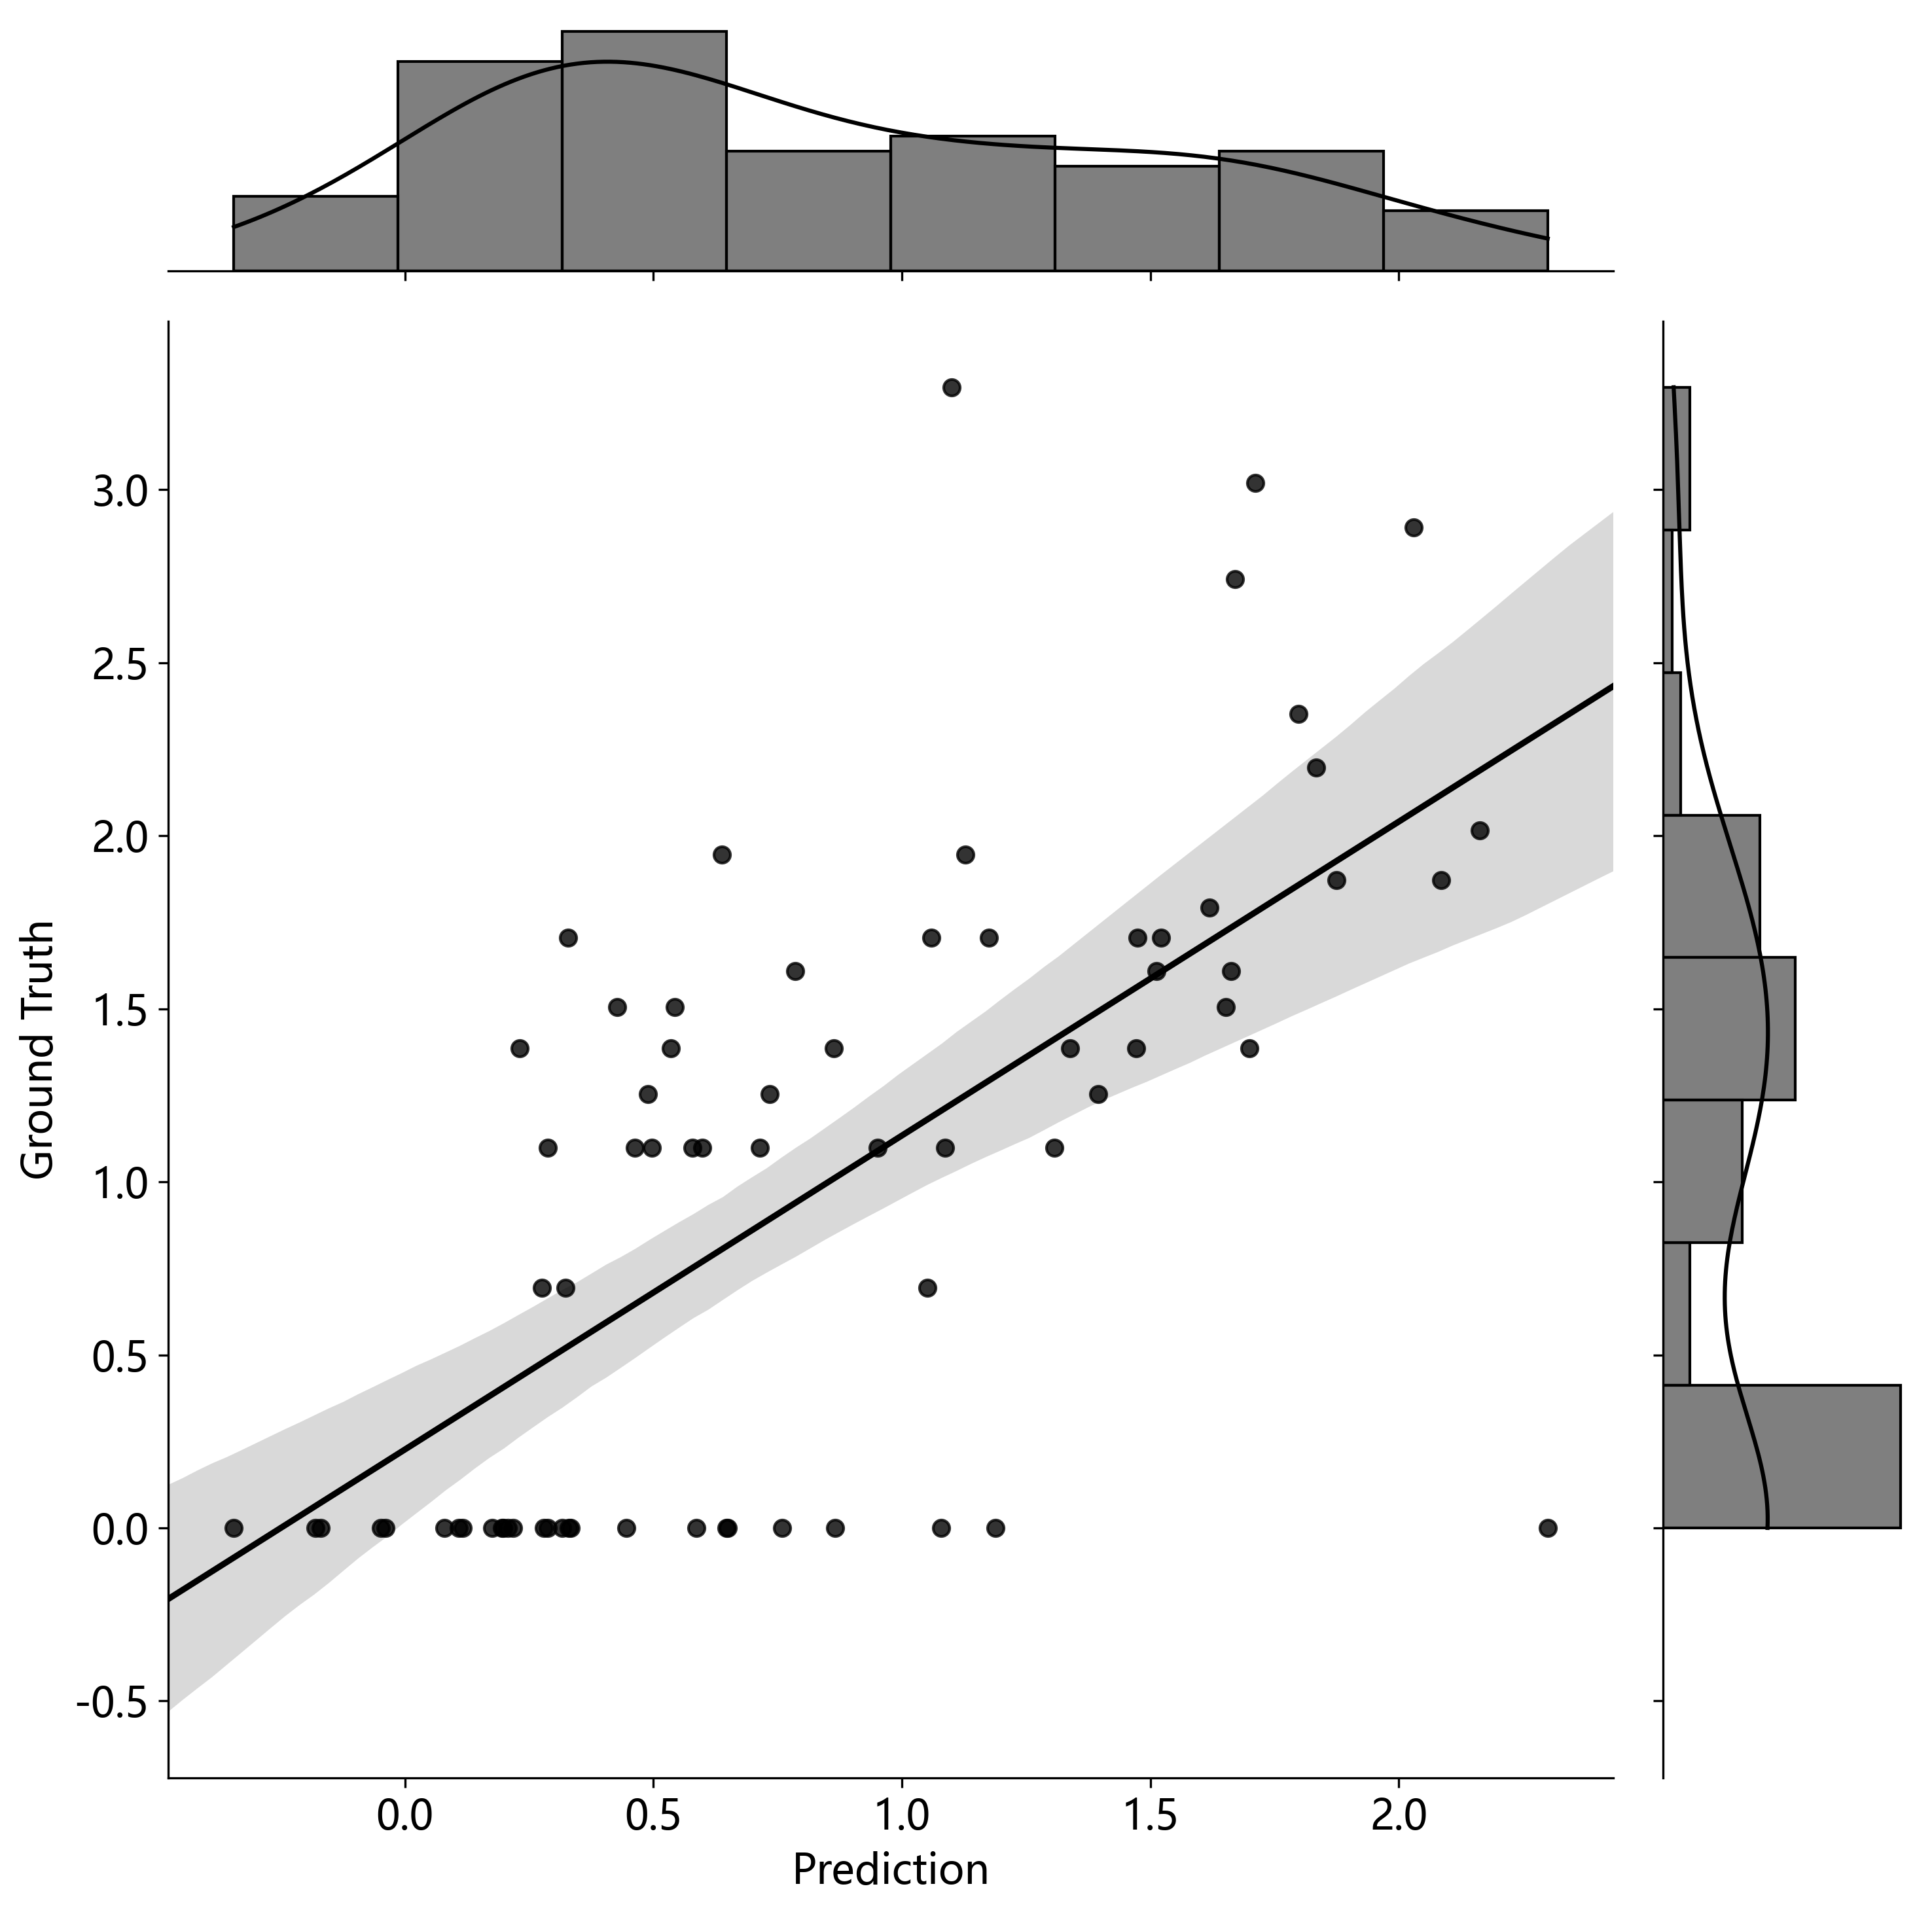

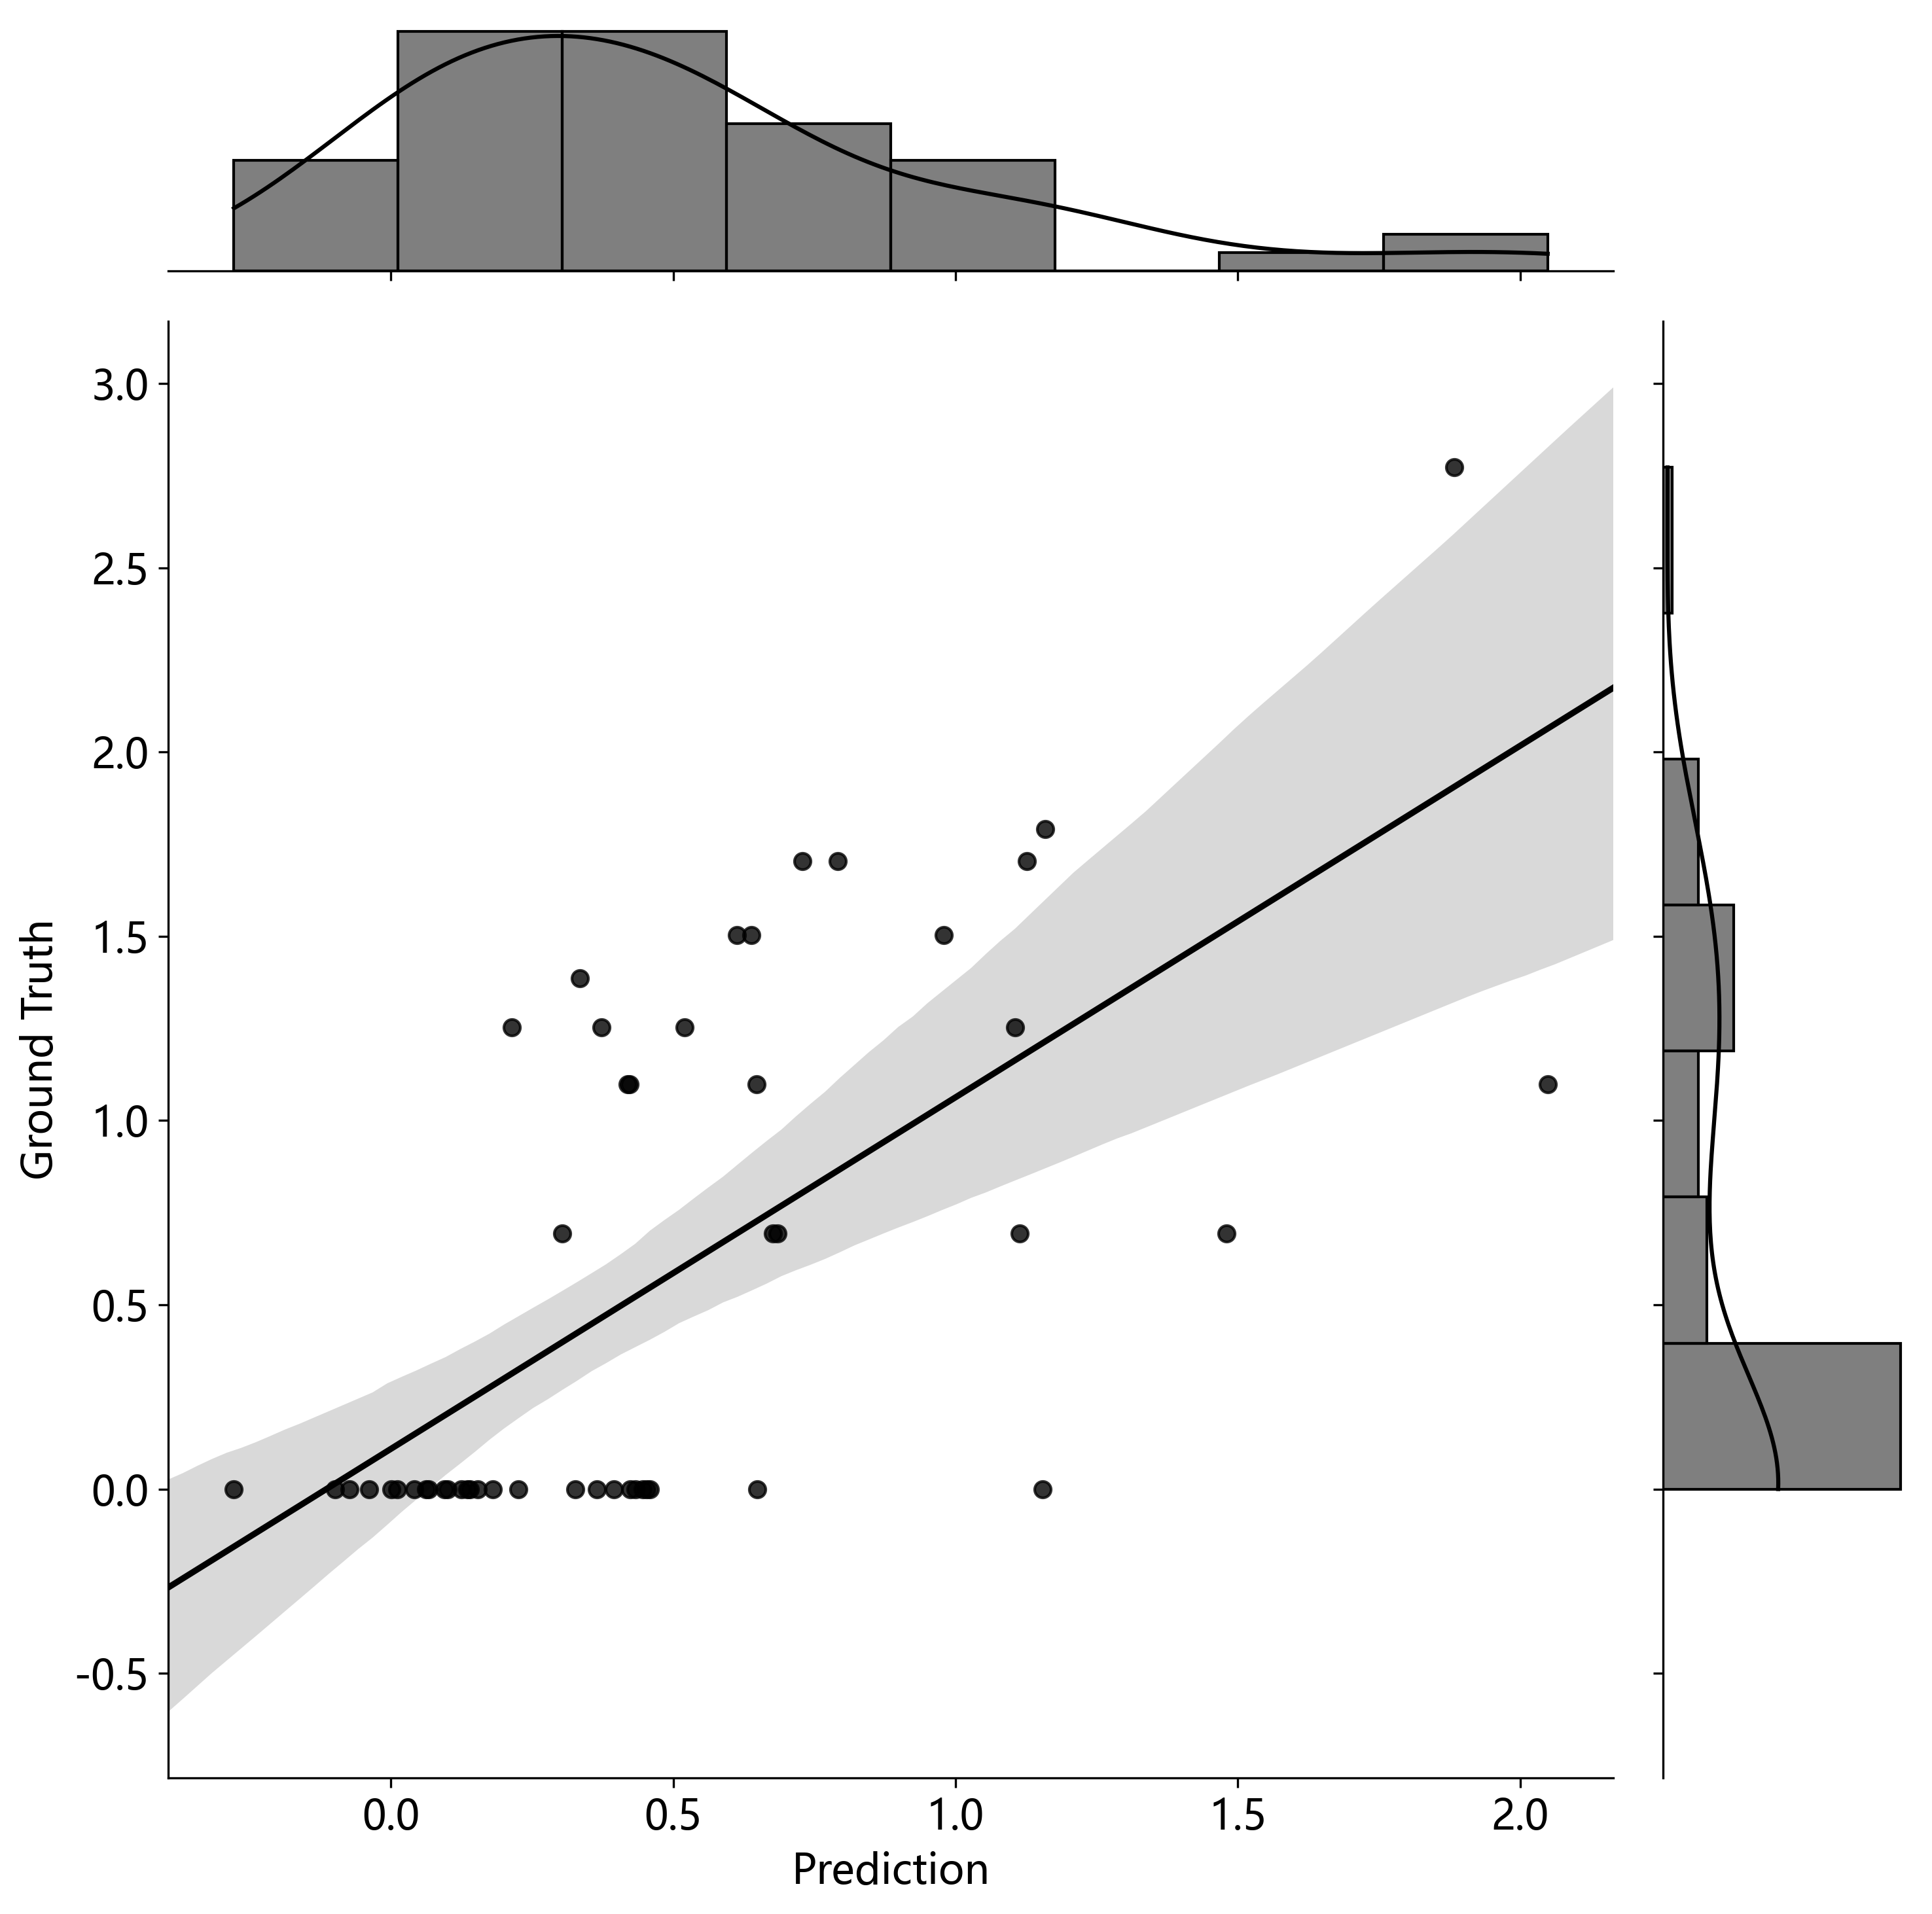

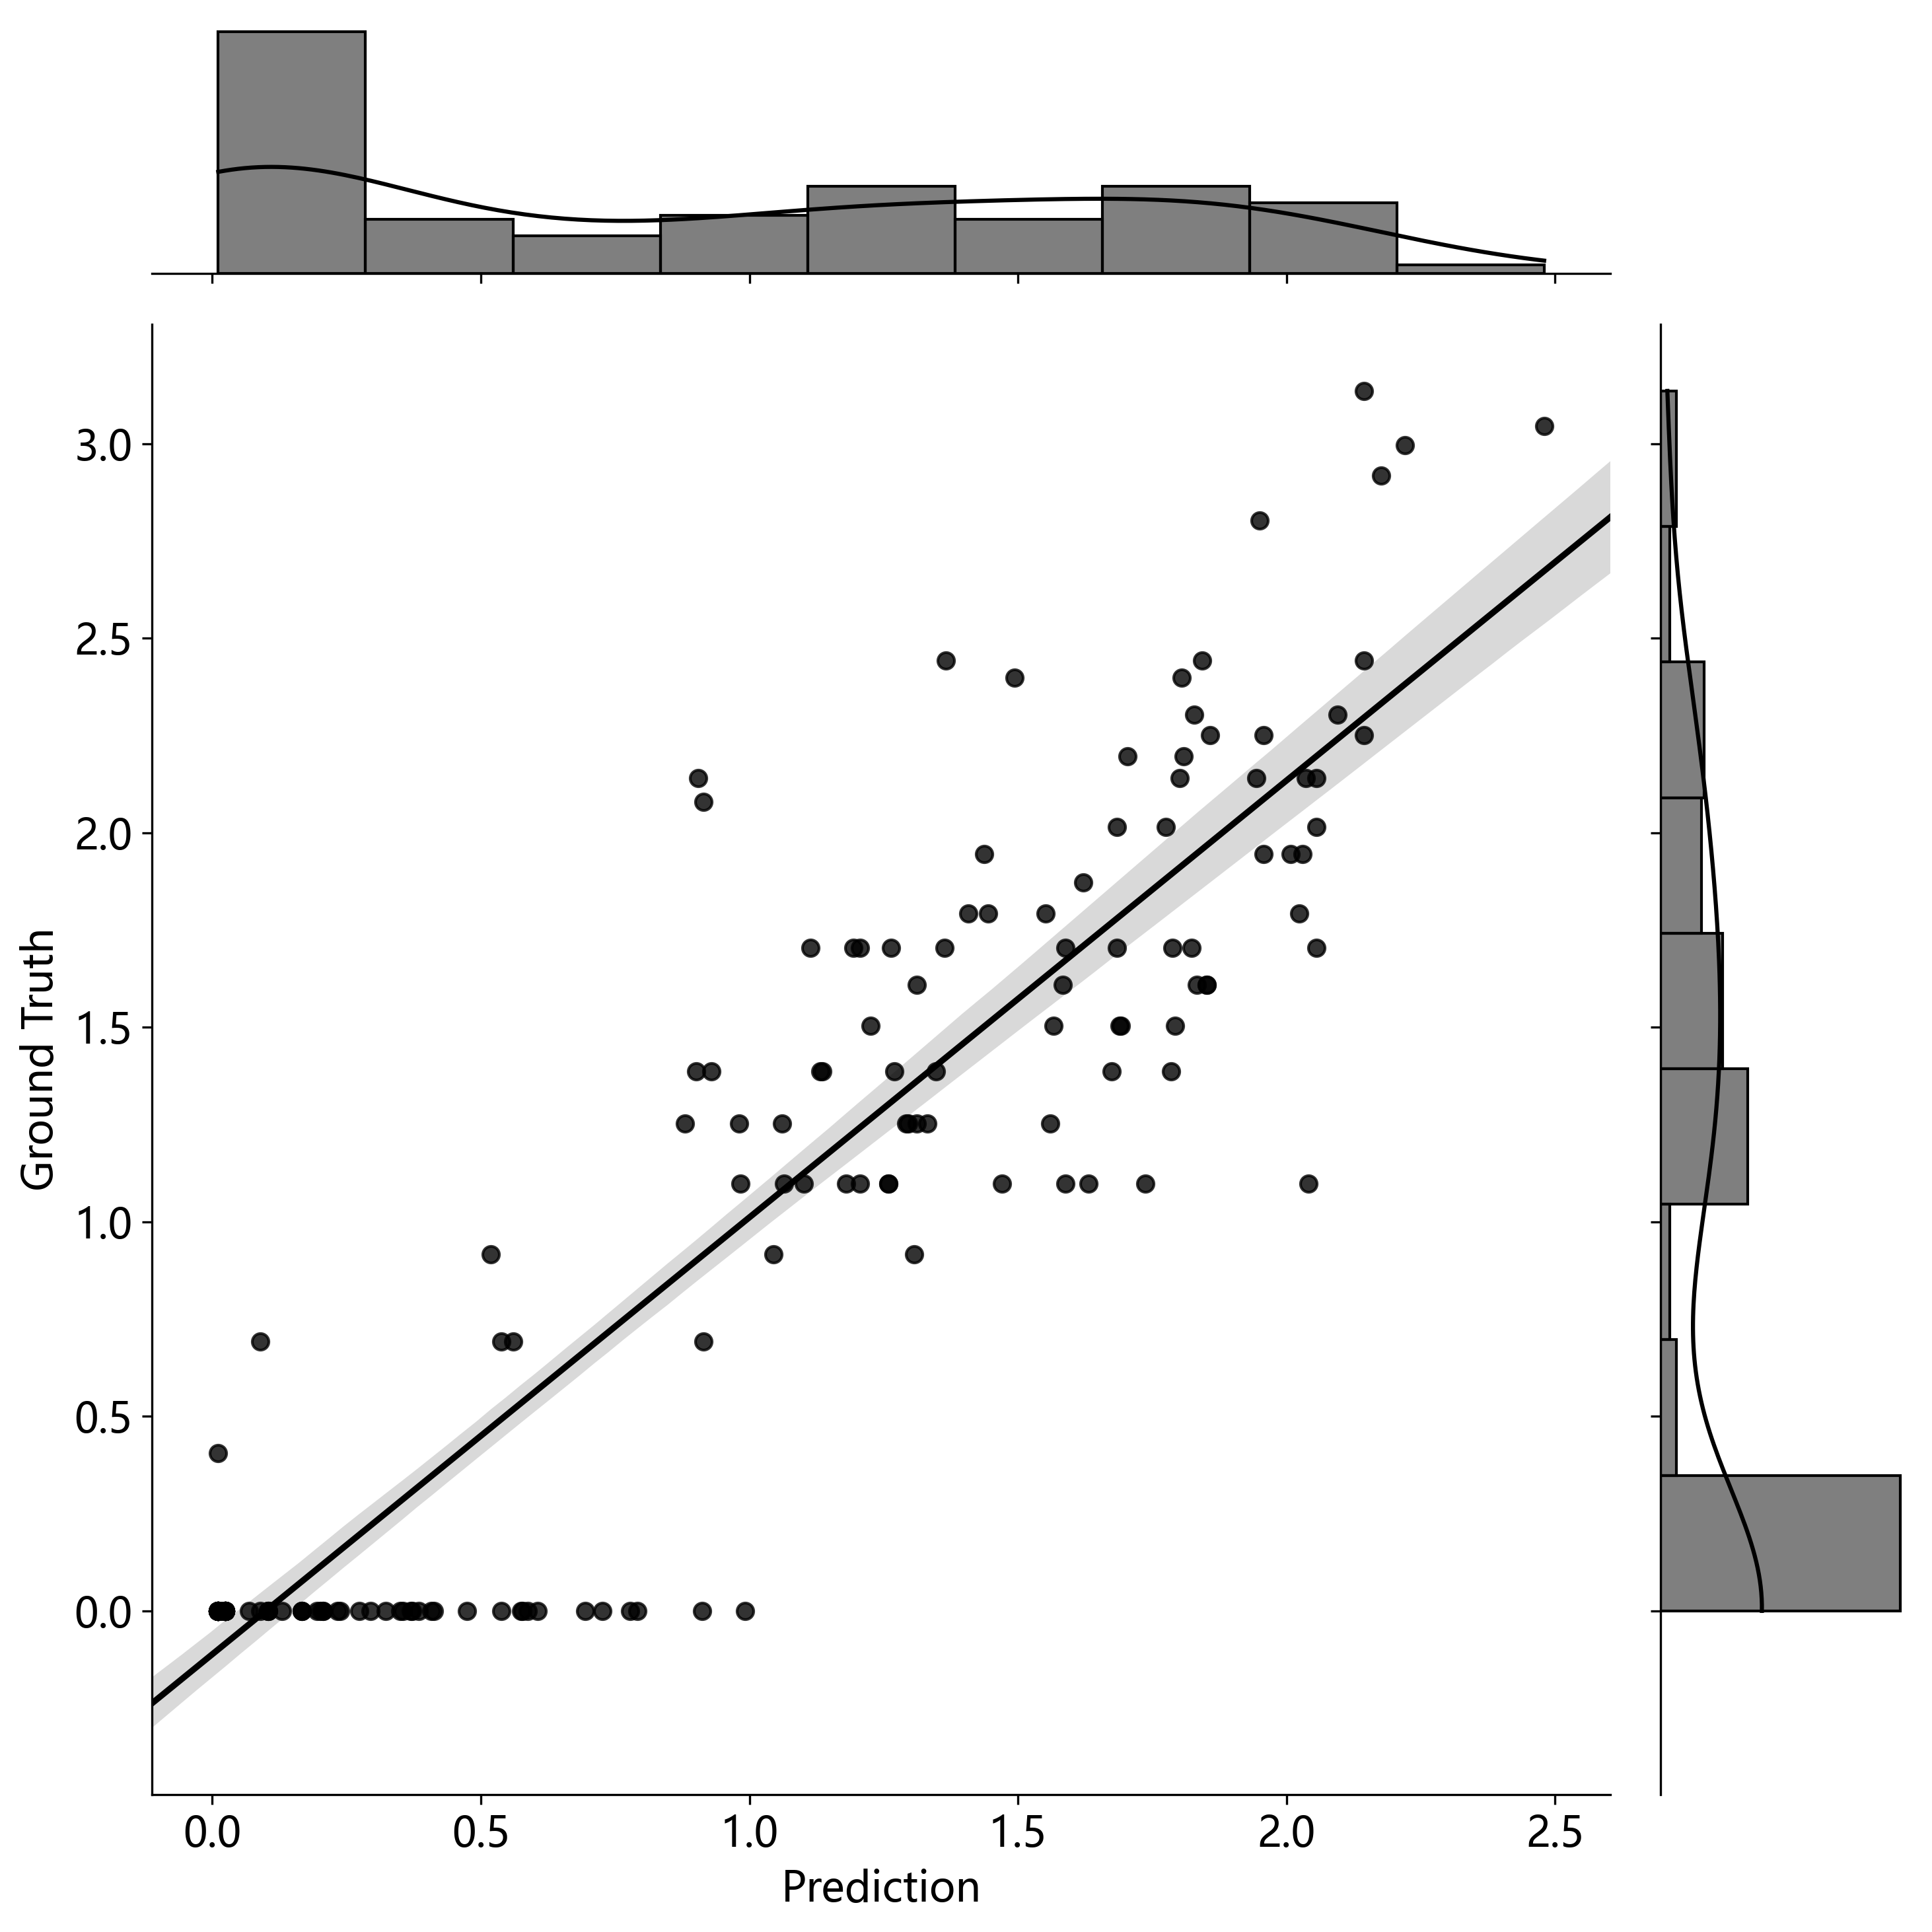

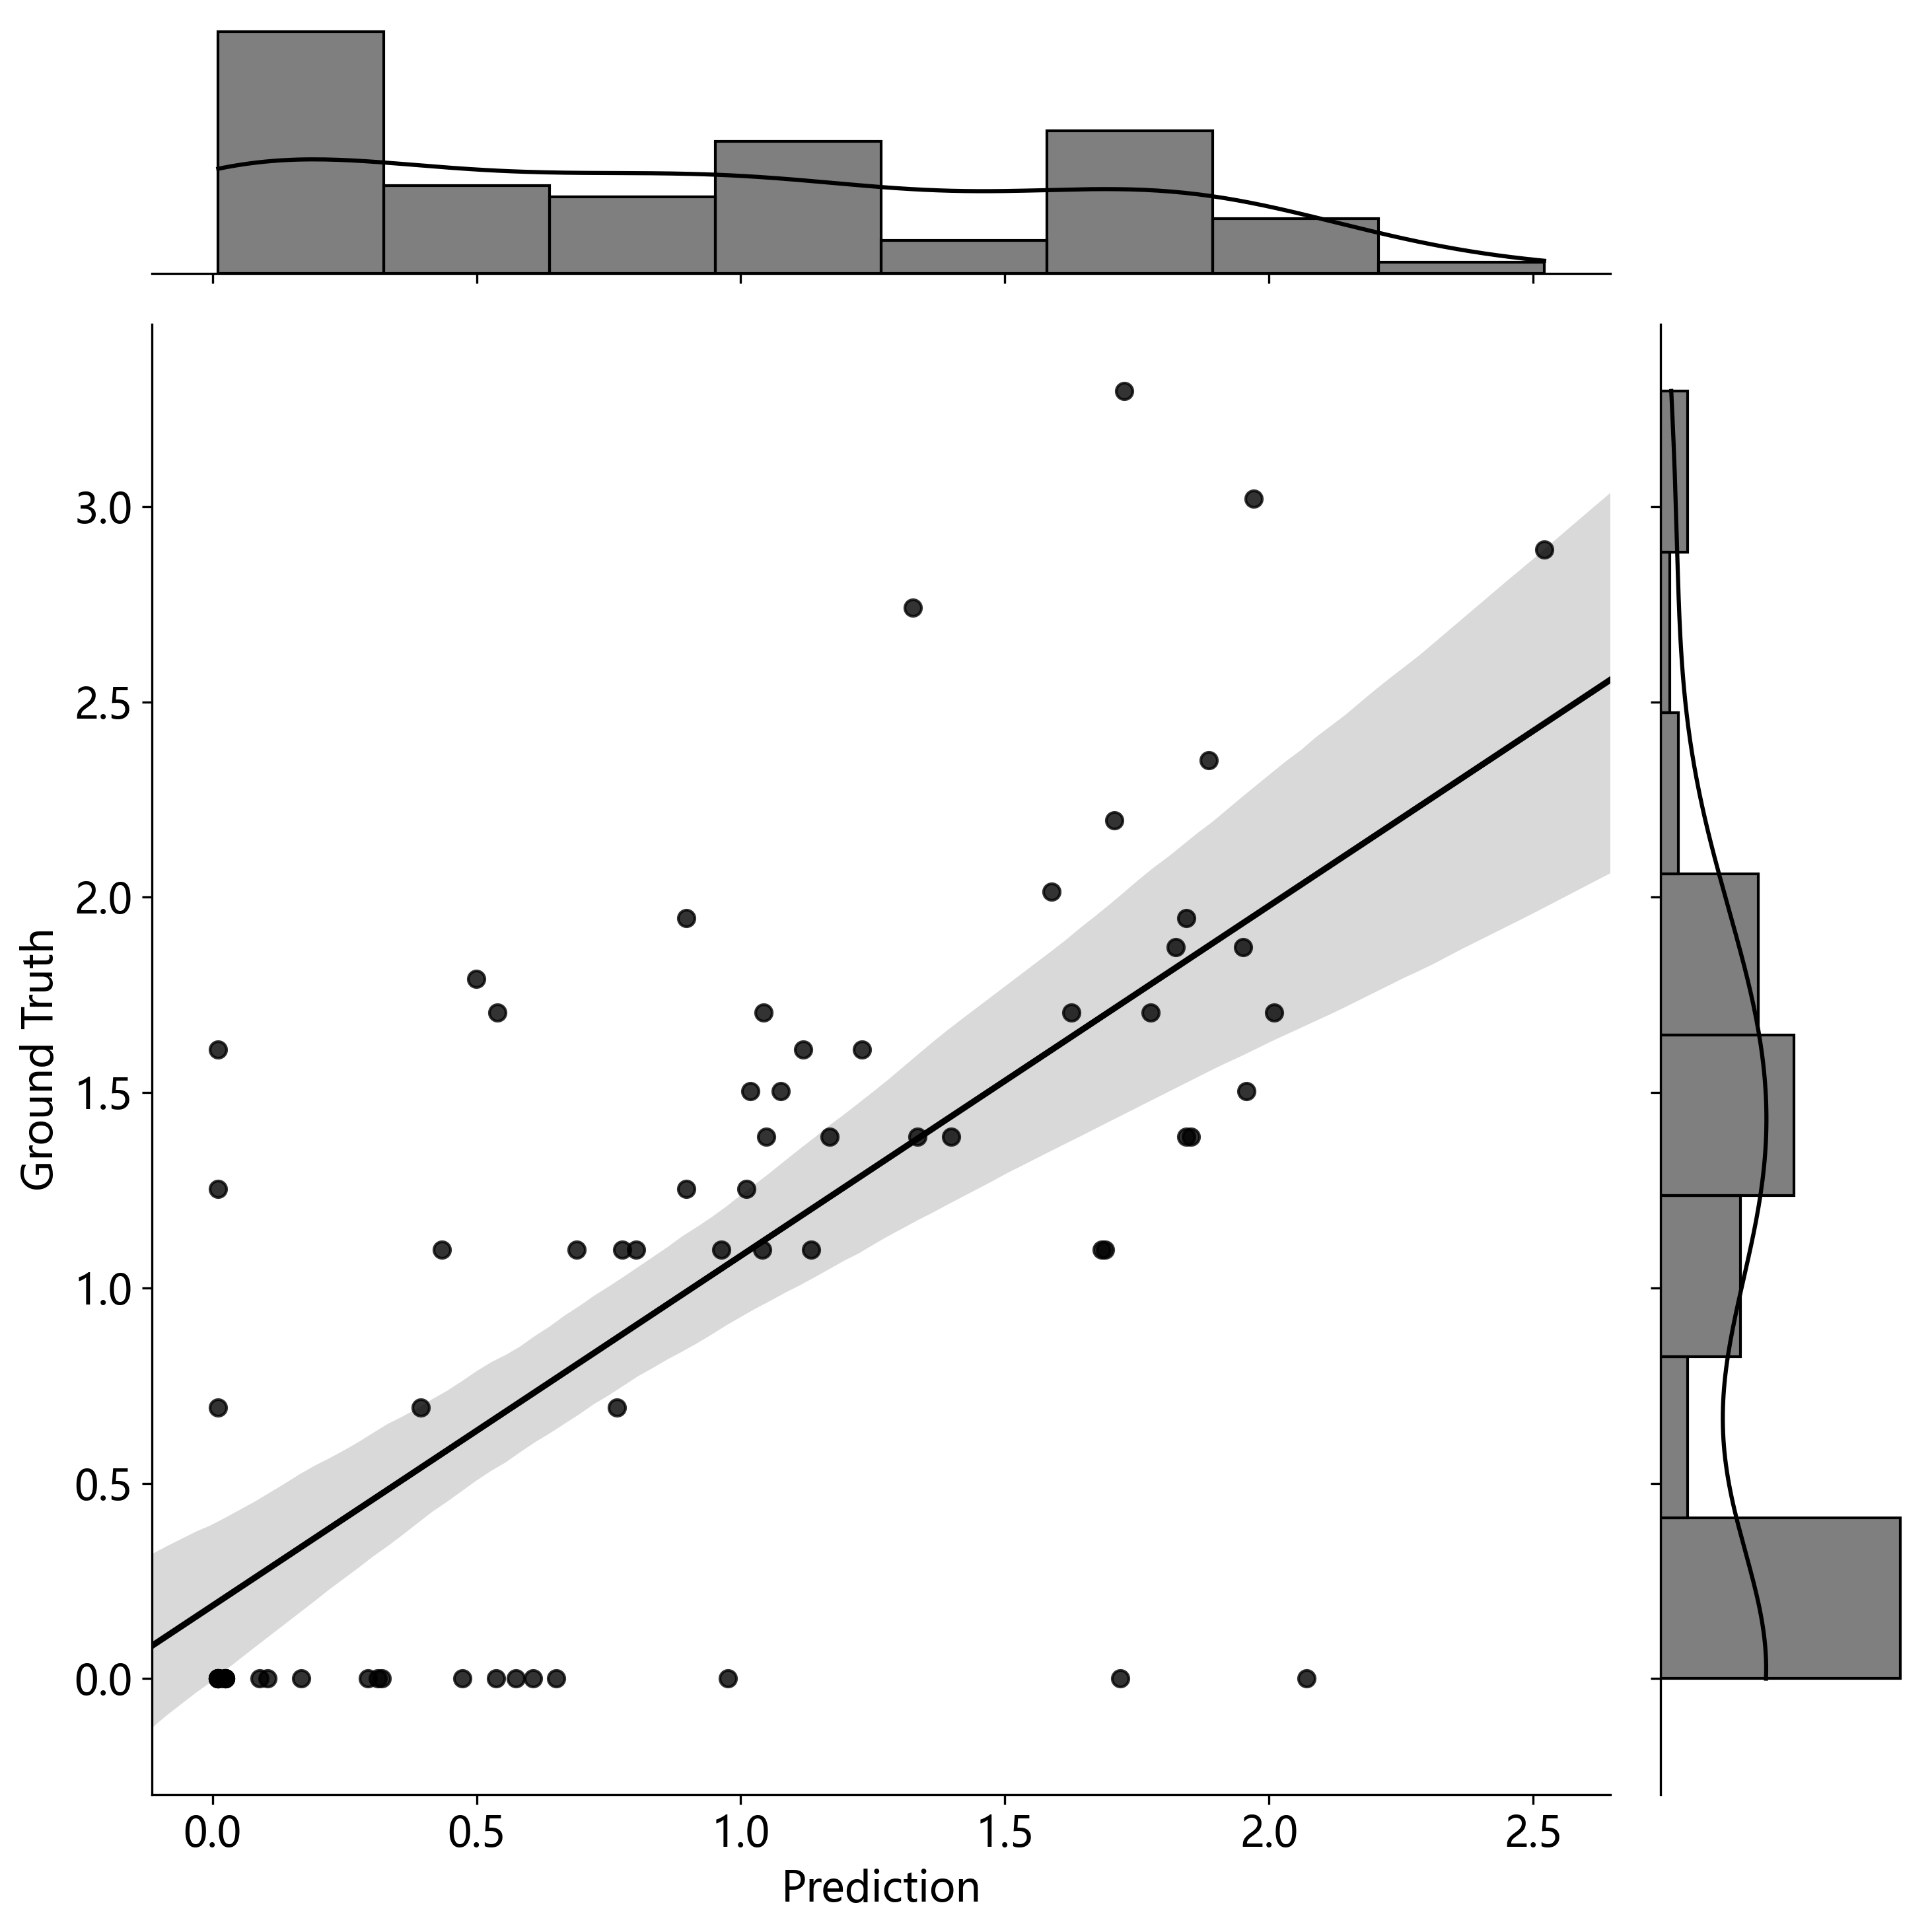

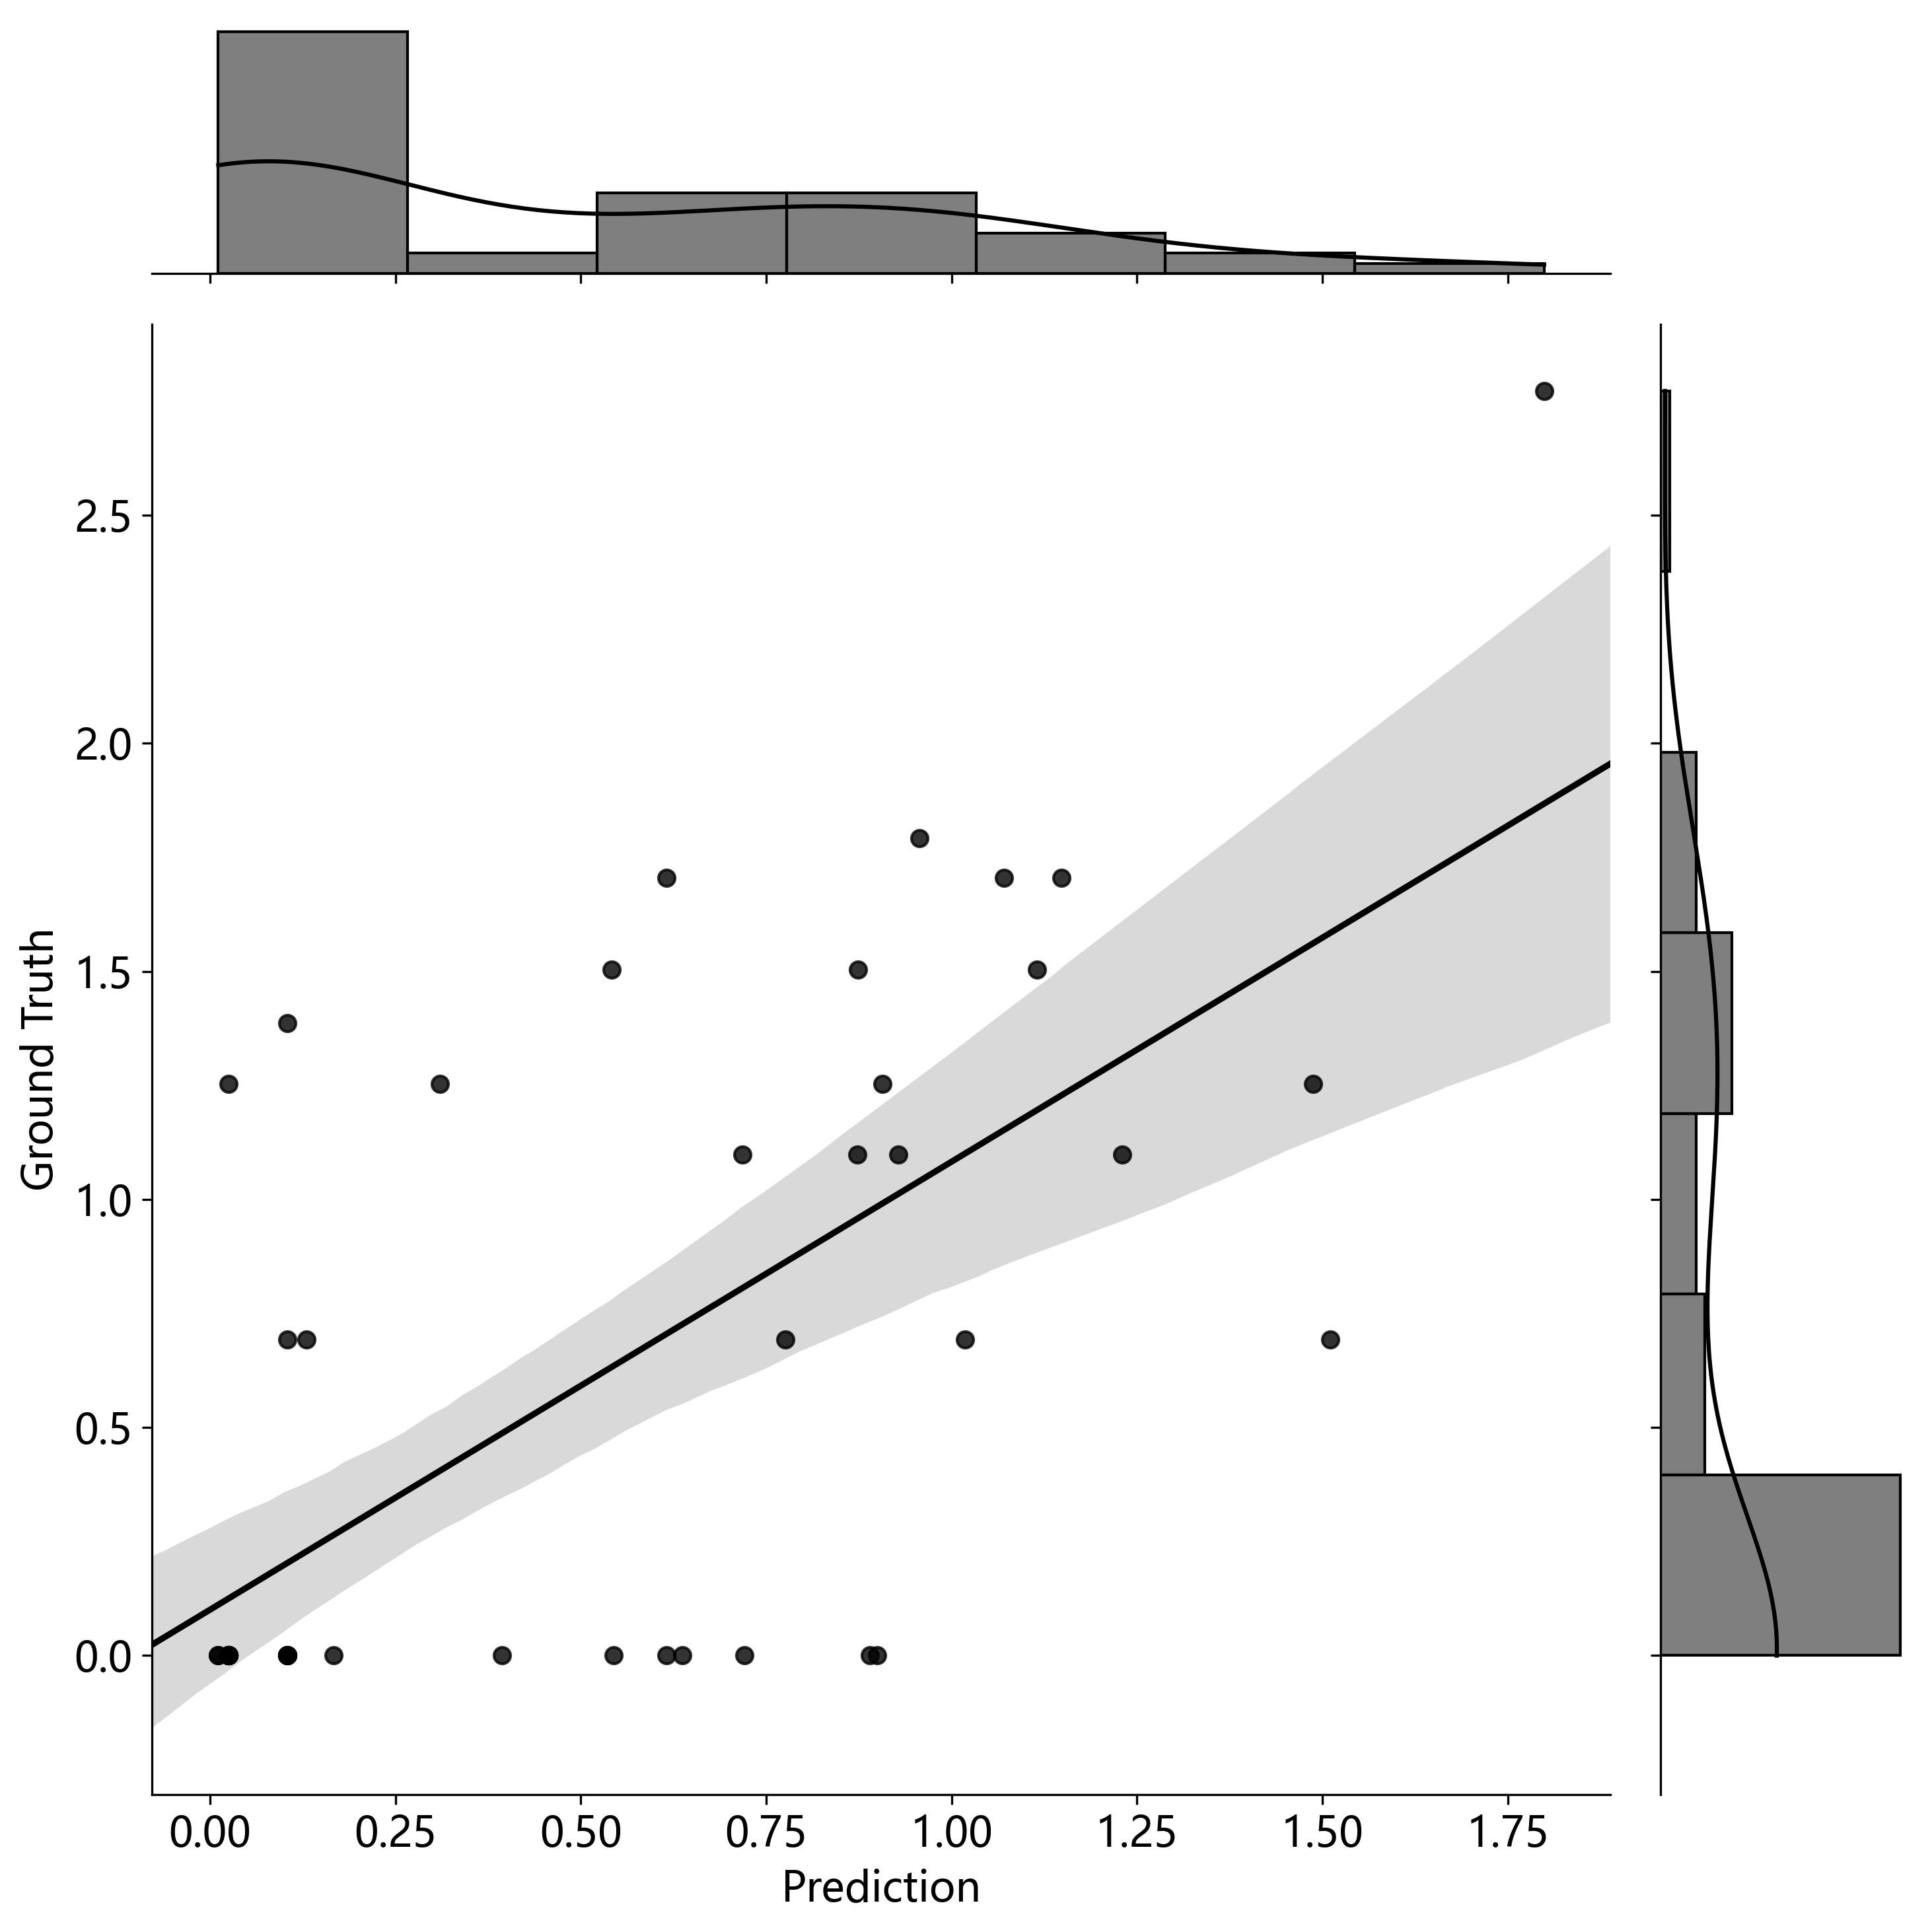

In [31]:
import os
import numpy as np
from onekey_algo import init_CN

init_CN()
os.makedirs('results', exist_ok=True)

for idx, label in enumerate(labels):
    for sm in model_names:
        sel_model_idx = model_names.index(sm)
        target = targets[idx][sel_model_idx]
        # 预测训练集和测试集数据。
        train_indexes = np.reshape(np.array(train_ids), (-1, 1)).astype(str)
        # 保存预测的训练集和测试集结果
        y_train_pred_scores = target.predict(X_data)
        columns = ['ID', 'Prediction']
        sns.set_palette(["black", "gray", "white"])
        result_train = pd.DataFrame(np.concatenate([train_indexes, 
                                                    np.reshape(y_train_pred_scores, (-1, 1))], axis=1), columns=columns)
        result_train.to_csv(f'results/{task_type}_{sm}_train.csv', index=False)
        r = pd.merge(result_train, label_data, on='ID', how='inner')
        r['Prediction'] = r['Prediction'].astype(float)
        r['Ground Truth'] = r['label']
        sns.jointplot(y="Ground Truth", x="Prediction", data=r,  kind="reg", truncate=False, height=10)
        plt.savefig(f'img/{task_type}_{sm}_train_regression.svg', bbox_inches='tight')
        plt.show()
        for subset, (X_val_sel, y_val_sel, val_ids) in val_datasets.items():
            val_indexes = np.reshape(np.array(val_ids), (-1, 1)).astype(str)
            y_val_pred_scores = target.predict(X_val_sel)
            result_val = pd.DataFrame(np.concatenate([val_indexes, np.reshape(y_val_pred_scores, (-1, 1))], axis=1), columns=columns)
            result_val.to_csv(f'results/{task_type}_{sm}_{subset}.csv', index=False)
            
            r = pd.merge(result_val, label_data, on='ID', how='inner')
            r['Prediction'] = r['Prediction'].astype(float)
            r['Ground Truth'] = r['label']
            sns.jointplot(y="Ground Truth", x="Prediction", data=r,  kind="reg", truncate=False, height=10)
            plt.savefig(f'img/{task_type}_{sm}_{subset}_regression.svg', bbox_inches='tight')
            plt.show()

In [36]:
metrics = []
sel_model = get_param_in_cwd('sel_model')
for mn in get_param_in_cwd('summary_models'):
    metric = pd.read_csv(f'results/{mn}_regression.csv')
    metric = metric[metric['model_name'] == sel_model[mn]]
    metric['Signature'] = mn
    metrics.append(metric)
pd.concat(metrics, axis=0)

,model_name,MSE,MAPE,Cohort,Signature
0,SVM,0.170,0.264,train,Clinical
1,SVM,0.423,0.472,val,Clinical
2,SVM,0.527,0.565,test,Clinical
6,densenet121,0.779,0.803,train,DL2D
7,densenet121,0.663,0.742,val,DL2D
8,densenet121,0.552,0.678,test,DL2D
0,SVM,0.324,0.475,train,DLElapsed
1,SVM,0.591,0.624,val,DLElapsed
2,SVM,0.499,0.593,test,DLElapsed
3,RandomForest,0.146,0.270,train,Combined
